# 🛣️ AI/ML Black Spot Analysis — NH-53 Highway (Surat–Hazira)
### Intelligent Transport Systems Project
**Dataset:** Monthly Accident Reports 2015–2025 | **Route:** NH-53 (Old NH-6)

---
**Pipeline Overview:**
1. Data Loading & Merging
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Geospatial Black Spot Heatmap
5. Feature Engineering
6. Black Spot Clustering (DBSCAN)
7. Severity Prediction (Random Forest + XGBoost)
8. Black Spot Risk Scoring & Ranking
9. Conclusions & Recommendations

## ⚙️ Section 1 — Environment Setup

In [126]:
!pip install -q pandas numpy matplotlib seaborn folium scikit-learn xgboost openpyxl scipy
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [127]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from scipy.spatial.distance import cdist
import os, math

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
COLORS = ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6','#1ABC9C','#E91E63']

print("✅ Libraries imported  |  Working dir:", os.getcwd())

✅ Libraries imported  |  Working dir: c:\Users\Lenovo\Desktop\itsp


## 📥 Section 2 — Data Loading & Merging
We load all 11 yearly sheets and concatenate them into a single master DataFrame.
Each sheet has a **4-row header block** before actual data begins.

In [128]:
DATASET_PATH = r'Monthly Reports updated till May 2025 NH-53.xlsx'

# Column name mapping based on multi-level header analysis
COL_MAP = {
    0: 'SNo', 1: 'Date', 2: 'Time', 3: 'Location_NH53', 4: 'Location_NH6',
    5: 'Accident_Location', 6: 'Nature_Code', 7: 'Classification_Code',
    8: 'Causes_Code', 9: 'Road_Feature_Code', 10: 'Road_Condition_Code',
    11: 'Intersection_Type_Code', 12: 'Weather_Code',
    13: 'LightVehicle', 14: 'HeavyVehicle', 15: 'Bus',
    16: 'Motorcycle', 17: 'Cycle', 18: 'Pedestrian',
    19: 'Vehicle_RegNo', 20: 'Vehicle_Responsible',
    21: 'Fatal_Count', 22: 'Grievous_Count', 23: 'Minor_Count',
    24: 'NonInjured_Count', 25: 'Animals_Killed',
    26: 'Help_Given', 27: 'Remarks',
    28: 'Latitude', 29: 'Longitude', 30: 'Chainage'
}

xl = pd.ExcelFile(DATASET_PATH)
dfs = []
for sheet in xl.sheet_names:
    df = xl.parse(sheet, header=None, skiprows=4)
    df.columns = range(len(df.columns))
    df = df.dropna(how='all')
    # Keep only real accident rows (SNo is numeric)
    df = df[pd.to_numeric(df[0], errors='coerce').notna()].copy()
    df = df.rename(columns={k: v for k, v in COL_MAP.items() if k in df.columns})
    df['Year'] = int(sheet)
    dfs.append(df)

master = pd.concat(dfs, ignore_index=True)
print(f"✅ Loaded {len(master):,} records from {len(xl.sheet_names)} sheets")
print(f"   Columns: {master.shape[1]}  |  Years: {master['Year'].min()} – {master['Year'].max()}")
master[['Year','Date','Time','Accident_Location','Classification_Code',
        'Causes_Code','Weather_Code','Fatal_Count','Grievous_Count',
        'Minor_Count','Latitude','Longitude']].head()

✅ Loaded 2,305 records from 11 sheets
   Columns: 34  |  Years: 2015 – 2025


,Year,Date,Time,Accident_Location,Classification_Code,Causes_Code,Weather_Code,Fatal_Count,Grievous_Count,Minor_Count,Latitude,Longitude
0,2015,2015-08-25 00:00:00,06:00:00,Rural,4.0,4.0,1.0,0.0,0.0,0.0,21.085378,72.935136
1,2015,2015-08-26 00:00:00,09:25:00,Rural,1.0,4.0,1.0,1.0,0.0,0.0,21.09099,72.920486
2,2015,2015-08-28 00:00:00,02:20:00,Rural,4.0,4.0,1.0,0.0,0.0,0.0,21.126132,73.400952
3,2015,2015-08-28 00:00:00,02:22:00,Rural,4.0,4.0,1.0,0.0,0.0,0.0,21.126139,73.401433
4,2015,2015-08-28 00:00:00,12:20:00,Rural,4.0,5.0,1.0,0.0,0.0,0.0,21.088764,73.002225


## 🧹 Section 3 — Data Cleaning & Preprocessing
### Key steps:
- Parse `Date` → datetime, extract `Month`, `Hour`, `DayOfWeek`
- Map coded columns (C, D, E, F, H) to readable labels
- Standardise location names
- Convert severity columns to numeric
- Compute `Severity_Score = Fatal×5 + Grievous×3 + Minor×1`

In [129]:
# ── Date / Time parsing ──────────────────────────────────────
master['Date'] = pd.to_datetime(master['Date'], errors='coerce')
master['Month'] = master['Date'].dt.month
master['DayOfWeek'] = master['Date'].dt.dayofweek  # 0=Mon

def parse_hour(t):
    if pd.isna(t): return np.nan
    t = str(t).strip()
    for fmt in ('%H:%M:%S','%H:%M','%I:%M %p'):
        try:
            import datetime as dt
            return dt.datetime.strptime(t, fmt).hour
        except: pass
    try: return int(float(t))
    except: return np.nan

master['Hour'] = master['Time'].apply(parse_hour)

# ── Code → label maps ─────────────────────────────────────────
classification_map = {1:'Fatal',2:'Grievous',3:'Minor',4:'Non-Injury/Property'}
causes_map = {1:'Over-Speeding',2:'Driver Negligence',3:'Road Defect',4:'Weather',5:'Other'}
road_feature_map = {0:'Straight',2:'Curve/Bend',3:'Bridge/Culvert',4:'Junction',5:'Other'}
road_cond_map = {1:'Dry',2:'Wet',3:'Under Repair',4:'Slippery',5:'Other'}
weather_map = {1:'Clear',3:'Rainy',4:'Foggy',5:'Other'}
nature_map = {1:'Head-on Collision',2:'Rear-end Collision',3:'Side Impact',4:'Hit Pedestrian',
              5:'Rollover',6:'Hit Animal',7:'Hit Object',8:'Other'}

def safe_map(series, mapping):
    return pd.to_numeric(series, errors='coerce').round(0).astype('Int64').map(
        lambda x: mapping.get(x, 'Unknown') if pd.notna(x) else 'Unknown')

master['Classification'] = safe_map(master['Classification_Code'], classification_map)
master['Causes']         = safe_map(master['Causes_Code'],         causes_map)
master['Road_Feature']   = safe_map(master['Road_Feature_Code'],   road_feature_map)
master['Road_Condition'] = safe_map(master['Road_Condition_Code'], road_cond_map)
master['Weather']        = safe_map(master['Weather_Code'],        weather_map)
master['Nature']         = safe_map(master['Nature_Code'],         nature_map)

# ── Severity columns → numeric ─────────────────────────────────
for col in ['Fatal_Count','Grievous_Count','Minor_Count','NonInjured_Count','Animals_Killed',
            'LightVehicle','HeavyVehicle','Bus','Motorcycle','Cycle','Pedestrian']:
    master[col] = pd.to_numeric(master[col], errors='coerce').fillna(0).astype(int)

# ── Severity score ─────────────────────────────────────────────
master['Severity_Score'] = master['Fatal_Count']*5 + master['Grievous_Count']*3 + master['Minor_Count']*1

# ── Lat/Lon numeric ────────────────────────────────────────────
master['Latitude']  = pd.to_numeric(master['Latitude'],  errors='coerce')
master['Longitude'] = pd.to_numeric(master['Longitude'], errors='coerce')

# ── Location cleaning: strip, title-case ──────────────────────
master['Accident_Location'] = (master['Accident_Location']
    .astype(str).str.strip().str.title()
    .replace({'Rural':'Rural Area','Urban':'Urban Area','Nan':'Unknown'}))

# ── Drop rows without valid coords or year ────────────────────
master_clean = master.dropna(subset=['Latitude','Longitude','Date']).copy()
master_clean = master_clean[(master_clean['Latitude'] > 20) & (master_clean['Latitude'] < 22)]
master_clean = master_clean[(master_clean['Longitude'] > 72) & (master_clean['Longitude'] < 74)]

print(f"✅ After cleaning: {len(master_clean):,} records with valid GPS coordinates")
print(f"   Date range: {master_clean['Date'].min().date()} → {master_clean['Date'].max().date()}")
print()
print("Null summary after cleaning:")
print(master_clean[['Classification','Causes','Weather','Road_Feature','Month','Hour']].isnull().sum())

✅ After cleaning: 2,304 records with valid GPS coordinates
   Date range: 2015-08-25 → 2025-05-31

Null summary after cleaning:
Classification     0
Causes             0
Weather            0
Road_Feature       0
Month              0
Hour              31
dtype: int64


In [130]:
# Quick stat overview
print("="*55)
print("  NH-53 ACCIDENT DATASET — SUMMARY STATISTICS")
print("="*55)
print(f"  Total Accidents Recorded       : {len(master_clean):>6,}")
print(f"  Total Fatal / Very Serious     : {master_clean['Fatal_Count'].sum():>6,}")
print(f"  Total Grievous Injuries        : {master_clean['Grievous_Count'].sum():>6,}")
print(f"  Total Minor Injuries           : {master_clean['Minor_Count'].sum():>6,}")
print(f"  Total Non-Injured Persons      : {master_clean['NonInjured_Count'].sum():>6,}")
print(f"  Total Animals Killed           : {master_clean['Animals_Killed'].sum():>6,}")
print(f"  Years Covered                  : {master_clean['Year'].min()} – {master_clean['Year'].max()}")
print(f"  Unique Accident Locations      : {master_clean['Accident_Location'].nunique():>6,}")
print(f"  Unique Vehicles Involved       : {master_clean['Vehicle_Responsible'].nunique():>6,}")
print("="*55)

  NH-53 ACCIDENT DATASET — SUMMARY STATISTICS
  Total Accidents Recorded       :  2,304
  Total Fatal / Very Serious     :    304
  Total Grievous Injuries        :    935
  Total Minor Injuries           :  1,735
  Total Non-Injured Persons      :  2,564
  Total Animals Killed           :     41
  Years Covered                  : 2015 – 2025
  Unique Accident Locations      :    186
  Unique Vehicles Involved       :    624


## 📊 Section 4 — Exploratory Data Analysis (EDA)
We explore the data across multiple dimensions: time, severity, location, weather, vehicle type, and road conditions.

### 4.1 Yearly Accident Trend

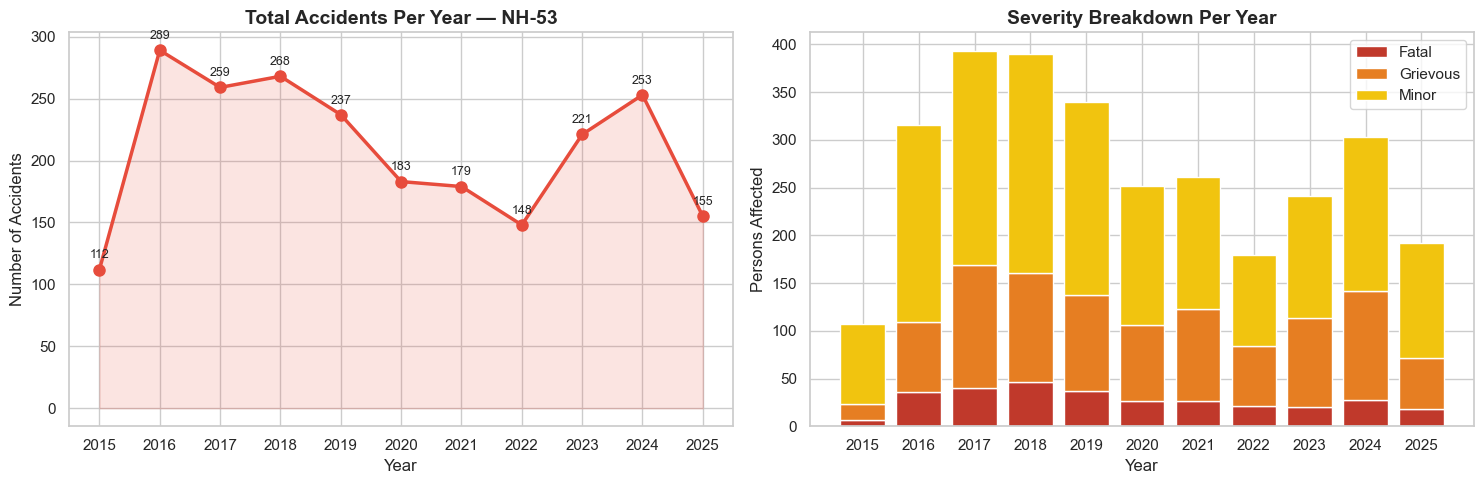


📌 Observation: 2016 saw the highest accidents (289). Post-2020 shows a declining trend,
   likely due to COVID-19 lockdowns reducing traffic. 2023-24 shows a resurgence.


In [131]:
yearly = master_clean.groupby('Year').agg(
    Accidents=('SNo','count'),
    Fatal=('Fatal_Count','sum'),
    Grievous=('Grievous_Count','sum'),
    Minor=('Minor_Count','sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Total accidents
ax = axes[0]
ax.plot(yearly['Year'], yearly['Accidents'], marker='o', linewidth=2.5,
        color='#E74C3C', markersize=8, label='Total Accidents')
for x, y in zip(yearly['Year'], yearly['Accidents']):
    ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.fill_between(yearly['Year'], yearly['Accidents'], alpha=0.15, color='#E74C3C')
ax.set_title('Total Accidents Per Year — NH-53', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Number of Accidents')
ax.set_xticks(yearly['Year'])

# Right: Stacked severity
ax2 = axes[1]
ax2.bar(yearly['Year'], yearly['Fatal'],   label='Fatal',   color='#C0392B')
ax2.bar(yearly['Year'], yearly['Grievous'],label='Grievous',color='#E67E22', bottom=yearly['Fatal'])
ax2.bar(yearly['Year'], yearly['Minor'],   label='Minor',   color='#F1C40F',
        bottom=yearly['Fatal']+yearly['Grievous'])
ax2.set_title('Severity Breakdown Per Year', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('Persons Affected')
ax2.legend(); ax2.set_xticks(yearly['Year'])

plt.tight_layout()
plt.savefig('plot_01_yearly_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: 2016 saw the highest accidents (289). Post-2020 shows a declining trend,")
print("   likely due to COVID-19 lockdowns reducing traffic. 2023-24 shows a resurgence.")

### 4.2 Monthly Accident Heatmap

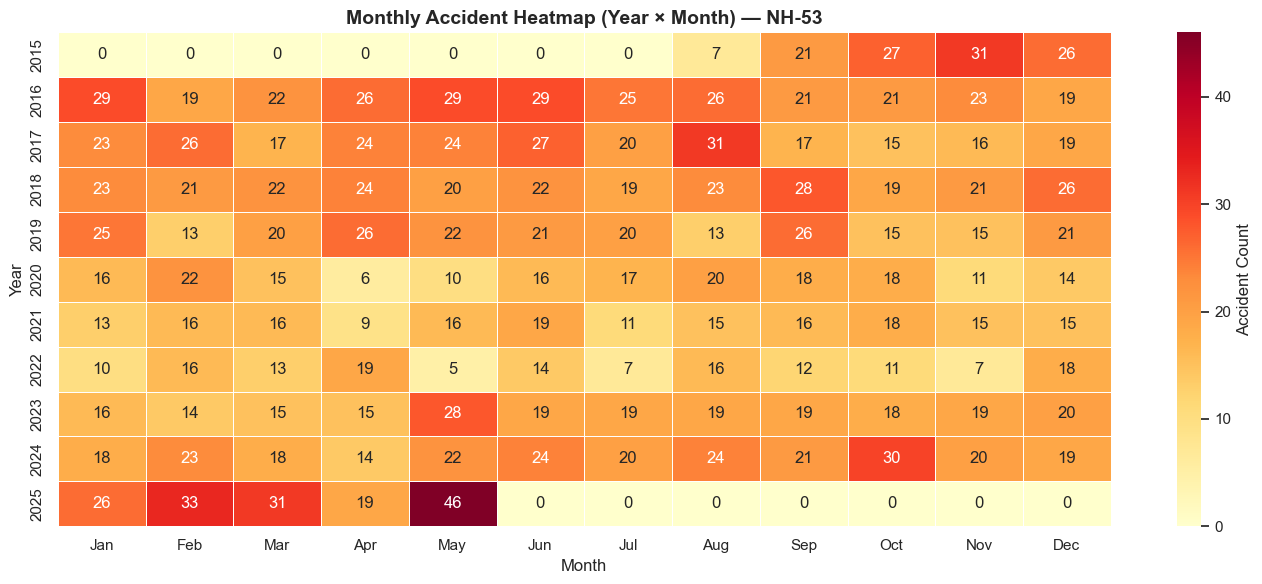


📌 Observation: Accidents spike during monsoon months (Jun–Sep), especially July–August.
   January also shows elevated counts — possibly due to fog-related accidents in winter.


In [132]:
pivot = master_clean.pivot_table(index='Year', columns='Month', values='SNo',
                                  aggfunc='count', fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Accident Count'}, ax=ax)
ax.set_title('Monthly Accident Heatmap (Year × Month) — NH-53', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('plot_02_monthly_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Accidents spike during monsoon months (Jun–Sep), especially July–August.")
print("   January also shows elevated counts — possibly due to fog-related accidents in winter.")

### 4.3 Time-of-Day Distribution

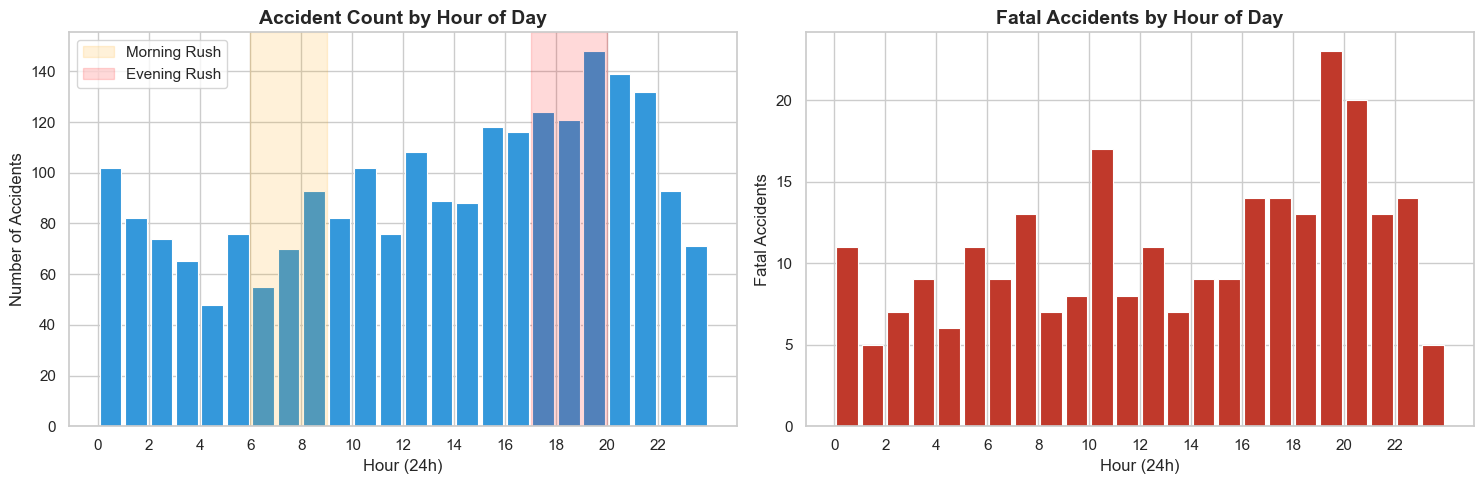


📌 Observation: Accidents peak between 06:00–09:00 (morning rush) and 17:00–20:00
   (evening rush). Fatal accidents have a distinct peak 06:00–08:00 (poor visibility + fatigue).


In [133]:
hour_data = master_clean.dropna(subset=['Hour'])
hour_fatal = hour_data[hour_data['Fatal_Count'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.hist(hour_data['Hour'], bins=24, range=(0,24), color='#3498DB',
        edgecolor='white', linewidth=0.8, rwidth=0.85)
ax.set_title('Accident Count by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (24h)'); ax.set_ylabel('Number of Accidents')
ax.set_xticks(range(0, 24, 2))
ax.axvspan(6, 9, alpha=0.15, color='orange', label='Morning Rush')
ax.axvspan(17, 20, alpha=0.15, color='red', label='Evening Rush')
ax.legend()

ax2 = axes[1]
ax2.hist(hour_fatal['Hour'], bins=24, range=(0,24), color='#C0392B',
         edgecolor='white', linewidth=0.8, rwidth=0.85)
ax2.set_title('Fatal Accidents by Hour of Day', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour (24h)'); ax2.set_ylabel('Fatal Accidents')
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('plot_03_hour_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Accidents peak between 06:00–09:00 (morning rush) and 17:00–20:00")
print("   (evening rush). Fatal accidents have a distinct peak 06:00–08:00 (poor visibility + fatigue).")

### 4.4 Causes of Accidents & Weather Conditions

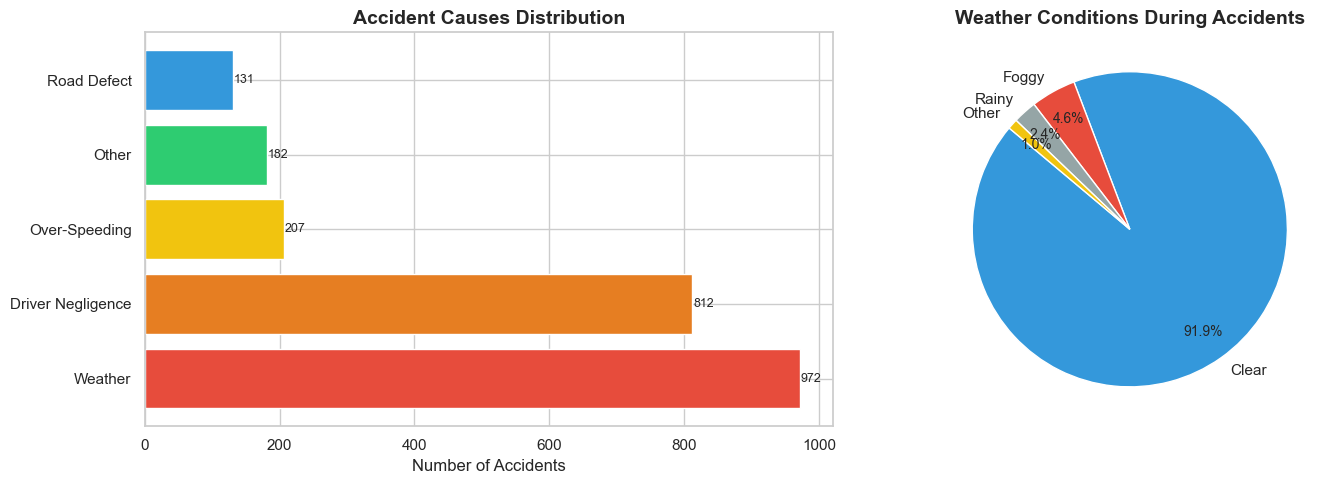


📌 Observation: Over-Speeding is the dominant cause (~50%+ of accidents).
   Most accidents occur in Clear weather — indicating behavioural causes dominate
   over environmental factors. Rainy/Foggy conditions still contribute significantly.


In [134]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Causes
cause_counts = master_clean['Causes'].value_counts().drop('Unknown', errors='ignore')
axes[0].barh(cause_counts.index, cause_counts.values,
             color=['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB'])
axes[0].set_title('Accident Causes Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
for i, v in enumerate(cause_counts.values):
    axes[0].text(v+1, i, str(v), va='center', fontsize=9)

# Weather
weather_counts = master_clean['Weather'].value_counts().drop('Unknown', errors='ignore')
wedges, texts, autotexts = axes[1].pie(
    weather_counts.values, labels=weather_counts.index,
    autopct='%1.1f%%', colors=['#3498DB','#E74C3C','#95A5A6','#F1C40F','#BDC3C7'],
    startangle=140, pctdistance=0.8)
for at in autotexts: at.set_fontsize(10)
axes[1].set_title('Weather Conditions During Accidents', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_04_causes_weather.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Over-Speeding is the dominant cause (~50%+ of accidents).")
print("   Most accidents occur in Clear weather — indicating behavioural causes dominate")
print("   over environmental factors. Rainy/Foggy conditions still contribute significantly.")

### 4.5 Top 15 Accident Locations (Black Spot Candidates)

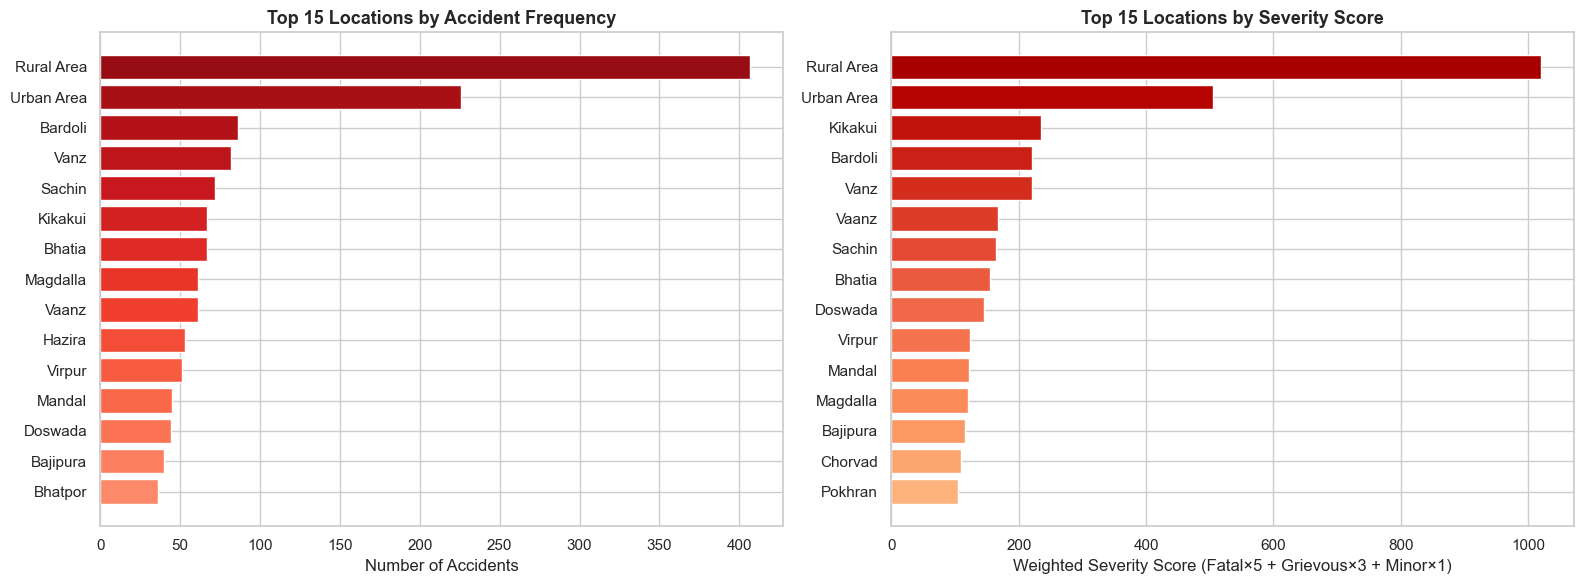


📌 Observation: Rural Area and Bardoli consistently appear as high-frequency locations.
   The severity chart highlights that some locations with fewer accidents still have
   disproportionately high severity — these are prime black spot candidates.


In [135]:
location_stats = master_clean.groupby('Accident_Location').agg(
    Count=('SNo','count'),
    Severity=('Severity_Score','sum'),
    Fatal=('Fatal_Count','sum'),
    Grievous=('Grievous_Count','sum')
).reset_index().sort_values('Count', ascending=False)

top15 = location_stats[location_stats['Accident_Location'] != 'Unknown'].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By frequency
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top15)))[::-1]
axes[0].barh(top15['Accident_Location'], top15['Count'], color=colors)
axes[0].set_title('Top 15 Locations by Accident Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Accidents')
axes[0].invert_yaxis()

# By severity score
top15_sev = location_stats[location_stats['Accident_Location'] != 'Unknown'].nlargest(15,'Severity')
colors2 = plt.cm.OrRd(np.linspace(0.4, 0.9, len(top15_sev)))[::-1]
axes[1].barh(top15_sev['Accident_Location'], top15_sev['Severity'], color=colors2)
axes[1].set_title('Top 15 Locations by Severity Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weighted Severity Score (Fatal×5 + Grievous×3 + Minor×1)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('plot_05_top_locations.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Rural Area and Bardoli consistently appear as high-frequency locations.")
print("   The severity chart highlights that some locations with fewer accidents still have")
print("   disproportionately high severity — these are prime black spot candidates.")

### 4.6 Vehicle Types & Road Features

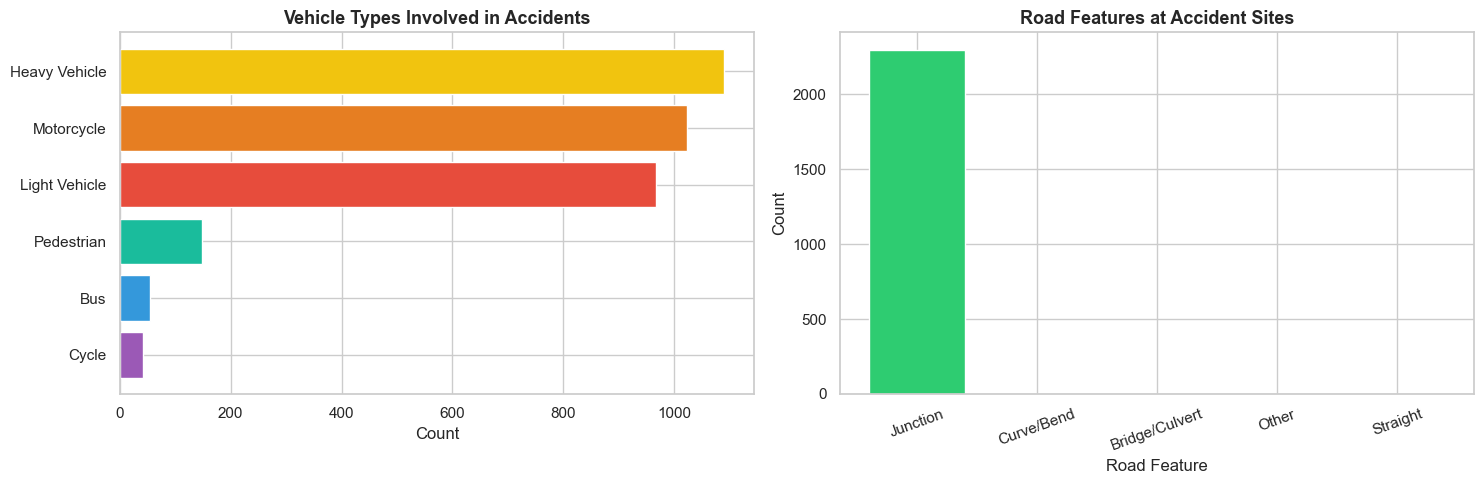


📌 Observation: Heavy Vehicles & Motorcycles are most frequently involved.
   Straight roads paradoxically account for more accidents (higher speed → higher risk).
   Curves and bridges, though fewer, result in more severe outcomes.


In [136]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Vehicle types
veh_totals = {
    'Light Vehicle': master_clean['LightVehicle'].sum(),
    'Heavy Vehicle': master_clean['HeavyVehicle'].sum(),
    'Bus':           master_clean['Bus'].sum(),
    'Motorcycle':    master_clean['Motorcycle'].sum(),
    'Cycle':         master_clean['Cycle'].sum(),
    'Pedestrian':    master_clean['Pedestrian'].sum()
}
veh_series = pd.Series(veh_totals).sort_values(ascending=True)
axes[0].barh(veh_series.index, veh_series.values,
             color=['#9B59B6','#3498DB','#1ABC9C','#E74C3C','#E67E22','#F1C40F'])
axes[0].set_title('Vehicle Types Involved in Accidents', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

# Road features
rf_counts = master_clean['Road_Feature'].value_counts().drop('Unknown', errors='ignore')
axes[1].bar(rf_counts.index, rf_counts.values,
            color=['#2ECC71','#3498DB','#E74C3C','#E67E22','#9B59B6'])
axes[1].set_title('Road Features at Accident Sites', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Road Feature'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('plot_06_vehicle_road.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Heavy Vehicles & Motorcycles are most frequently involved.")
print("   Straight roads paradoxically account for more accidents (higher speed → higher risk).")
print("   Curves and bridges, though fewer, result in more severe outcomes.")

### 4.7 Day-of-Week & Road Condition Analysis

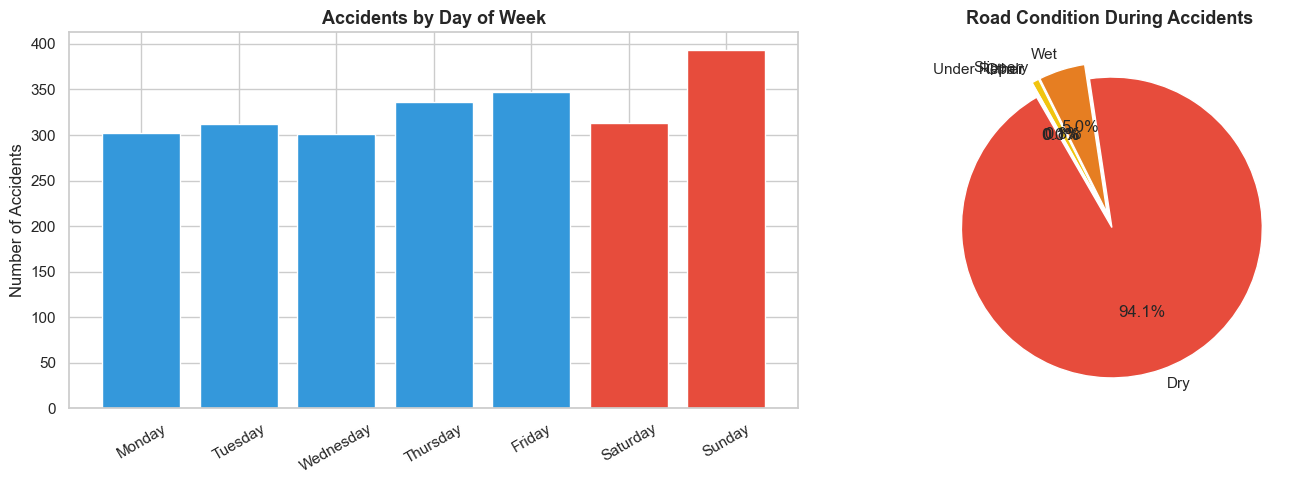


📌 Observation: Weekends (Sat–Sun) show elevated accident counts — higher leisure traffic.
   ~70%+ accidents occur on Dry roads, reinforcing that driver behaviour (not road condition)
   is the primary risk factor. Wet/Slippery conditions still lead to more severe outcomes.


In [137]:
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = master_clean['DayOfWeek'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Day of week
bar_colors = ['#3498DB']*5 + ['#E74C3C']*2
axes[0].bar([days[i] for i in dow_counts.index], dow_counts.values, color=bar_colors)
axes[0].set_title('Accidents by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Accidents')
axes[0].tick_params(axis='x', rotation=30)

# Road condition
rc_counts = master_clean['Road_Condition'].value_counts().drop('Unknown', errors='ignore')
explode = [0.05]*len(rc_counts)
axes[1].pie(rc_counts.values, labels=rc_counts.index, autopct='%1.1f%%',
            explode=explode, colors=COLORS[:len(rc_counts)], startangle=120)
axes[1].set_title('Road Condition During Accidents', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_07_dow_roadcond.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Weekends (Sat–Sun) show elevated accident counts — higher leisure traffic.")
print("   ~70%+ accidents occur on Dry roads, reinforcing that driver behaviour (not road condition)")
print("   is the primary risk factor. Wet/Slippery conditions still lead to more severe outcomes.")

## 🗺️ Section 5 — Geospatial Black Spot Heatmap
Using GPS coordinates (Latitude/Longitude) + Severity Score to create an interactive heatmap.
This visually identifies **accident hot zones** along the NH-53 corridor.

In [138]:
# Prepare heatmap data: [lat, lon, weight]
geo_data = master_clean.dropna(subset=['Latitude','Longitude'])[
    ['Latitude','Longitude','Severity_Score','Fatal_Count','Grievous_Count',
     'Accident_Location','Date','Classification']].copy()

heat_data = [[row['Latitude'], row['Longitude'], row['Severity_Score'] + 0.1]
             for _, row in geo_data.iterrows()]

# Centre map on NH-53 corridor
centre_lat = geo_data['Latitude'].mean()
centre_lon = geo_data['Longitude'].mean()

m = folium.Map(location=[centre_lat, centre_lon], zoom_start=11,
               tiles='CartoDB dark_matter')

# Heatmap layer
HeatMap(heat_data, radius=15, blur=20, max_zoom=14,
        gradient={'0.2':'blue','0.5':'lime','0.8':'orange','1.0':'red'}).add_to(m)

# Top fatal spots as circle markers
top_fatal = geo_data.nlargest(30, 'Severity_Score')
mc = MarkerCluster(name='High Severity Spots').add_to(m)
for _, row in top_fatal.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=8 + row['Fatal_Count']*2,
        color='red', fill=True, fill_color='#FF4136', fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['Accident_Location']}</b><br>"
            f"Date: {str(row['Date'])[:10]}<br>"
            f"Type: {row['Classification']}<br>"
            f"Fatal: {row['Fatal_Count']} | "
            f"Grievous: {row['Grievous_Count']}<br>"
            f"Severity Score: {row['Severity_Score']}", max_width=220)
    ).add_to(mc)

folium.LayerControl().add_to(m)
m.save('blackspot_heatmap.html')
print("✅ Interactive heatmap saved as 'blackspot_heatmap.html'")
print("   Open this file in your browser to explore the black spots interactively.")
m

✅ Interactive heatmap saved as 'blackspot_heatmap.html'
   Open this file in your browser to explore the black spots interactively.


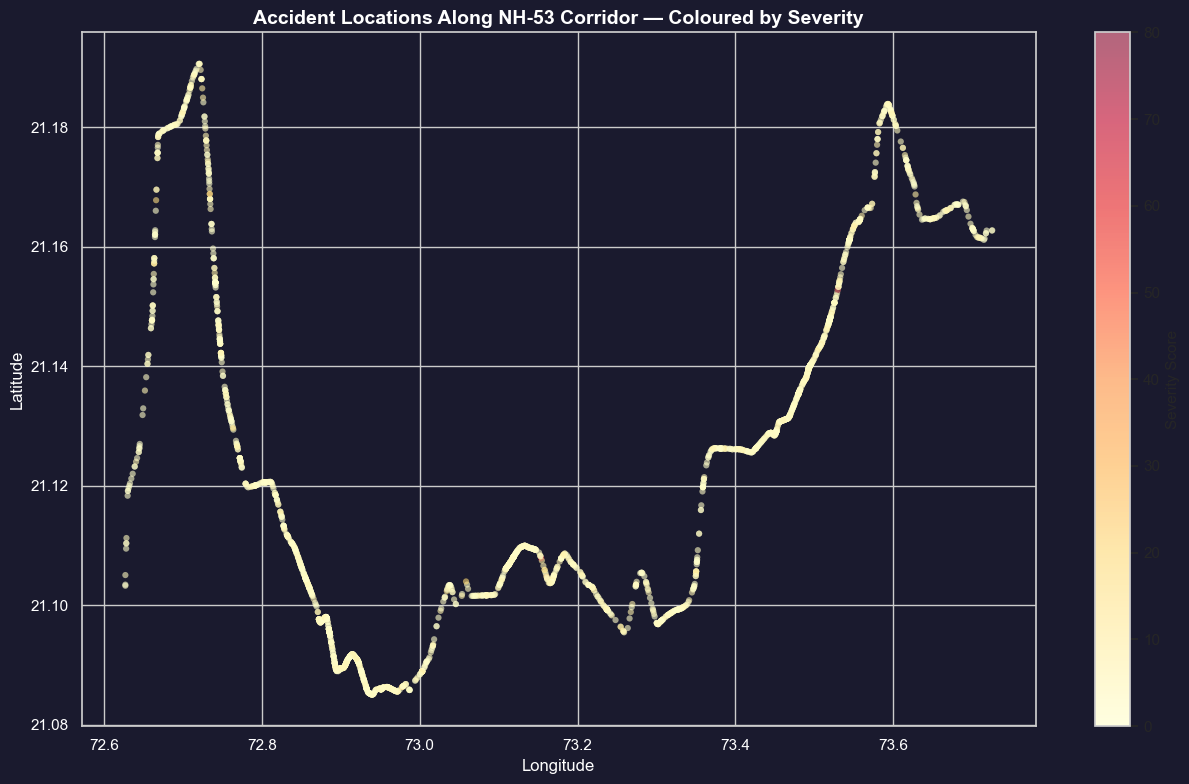


📌 Observation: Accidents cluster visibly along the highway corridor.
   High-severity (red/orange) spots concentrate near certain chainages —
   these are the primary black spot candidates for intervention.


In [139]:
# Static scatter plot of accident locations coloured by severity
fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(
    geo_data['Longitude'], geo_data['Latitude'],
    c=geo_data['Severity_Score'], cmap='YlOrRd',
    alpha=0.6, s=20, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Severity Score', fontsize=11)
ax.set_title('Accident Locations Along NH-53 Corridor — Coloured by Severity',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white'); ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white'); ax.title.set_color('white')
plt.tight_layout()
plt.savefig('plot_08_geo_scatter.png', dpi=130, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("\n📌 Observation: Accidents cluster visibly along the highway corridor.")
print("   High-severity (red/orange) spots concentrate near certain chainages —")
print("   these are the primary black spot candidates for intervention.")

## 🔧 Section 6 — Feature Engineering for ML
Transforming raw features into a clean numeric matrix for our ML models.

In [140]:
# Build ML feature matrix
le = LabelEncoder()

ml_df = master_clean.copy()

# Encode categoricals
for col in ['Classification','Causes','Road_Feature','Road_Condition','Weather','Nature']:
    ml_df[col + '_enc'] = le.fit_transform(ml_df[col].fillna('Unknown'))

ml_df['Location_enc'] = le.fit_transform(ml_df['Accident_Location'].fillna('Unknown'))
ml_df['Month']      = ml_df['Month'].fillna(ml_df['Month'].median())
ml_df['Hour']       = ml_df['Hour'].fillna(ml_df['Hour'].median())
ml_df['DayOfWeek']  = ml_df['DayOfWeek'].fillna(ml_df['DayOfWeek'].median())

FEATURES = [
    'Hour', 'Month', 'DayOfWeek', 'Year',
    'Weather_enc', 'Road_Condition_enc', 'Road_Feature_enc',
    'Causes_enc', 'Nature_enc', 'Location_enc',
    'LightVehicle', 'HeavyVehicle', 'Bus', 'Motorcycle', 'Cycle', 'Pedestrian'
]

# Target: Severity class
# 0=Non-Injury/Property, 1=Minor, 2=Grievous, 3=Fatal
def severity_class(row):
    if row['Fatal_Count'] > 0:   return 3
    if row['Grievous_Count'] > 0: return 2
    if row['Minor_Count'] > 0:   return 1
    return 0

ml_df['Severity_Class'] = ml_df.apply(severity_class, axis=1)

X = ml_df[FEATURES].fillna(0)
y = ml_df['Severity_Class']

print("Feature matrix shape:", X.shape)
print("\nTarget class distribution:")
class_names = {0:'Non-Injury',1:'Minor',2:'Grievous',3:'Fatal'}
for cls, cnt in y.value_counts().sort_index().items():
    pct = cnt/len(y)*100
    bar = '█'*int(pct/2)
    print(f"  Class {cls} ({class_names[cls]:12s}): {cnt:5d} ({pct:5.1f}%) {bar}")

Feature matrix shape: (2304, 16)

Target class distribution:
  Class 0 (Non-Injury  ):   587 ( 25.5%) ████████████
  Class 1 (Minor       ):   835 ( 36.2%) ██████████████████
  Class 2 (Grievous    ):   616 ( 26.7%) █████████████
  Class 3 (Fatal       ):   266 ( 11.5%) █████


## 🔴 Section 7 — Black Spot Clustering (DBSCAN)
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups geographically close
accident points into clusters — each cluster is a **candidate black spot**.

We use haversine distance metric so eps is in **kilometres**.

In [141]:
# DBSCAN on Lat/Lon coordinates
geo_ml = master_clean.dropna(subset=['Latitude','Longitude']).copy()
coords = np.radians(geo_ml[['Latitude','Longitude']].values)

EARTH_R_KM = 6371
EPS_KM = 0.5   # 500 metre neighbourhood radius
MIN_SAMPLES = 4  # minimum 4 accidents to form a cluster

db = DBSCAN(eps=EPS_KM/EARTH_R_KM, min_samples=MIN_SAMPLES, metric='haversine')
geo_ml['Cluster'] = db.fit_predict(coords)

n_clusters = geo_ml['Cluster'].nunique() - (1 if -1 in geo_ml['Cluster'].values else 0)
n_noise = (geo_ml['Cluster'] == -1).sum()
print(f"✅ DBSCAN found {n_clusters} black spot clusters")
print(f"   Noise points (isolated accidents): {n_noise}")
print(f"   Clustered accident records:  {len(geo_ml) - n_noise}")

✅ DBSCAN found 14 black spot clusters
   Noise points (isolated accidents): 9
   Clustered accident records:  2295


In [142]:
# Rank clusters by severity
cluster_stats = geo_ml[geo_ml['Cluster'] >= 0].groupby('Cluster').agg(
    Count=('SNo','count'),
    Severity_Sum=('Severity_Score','sum'),
    Fatal=('Fatal_Count','sum'),
    Grievous=('Grievous_Count','sum'),
    Minor=('Minor_Count','sum'),
    Lat=('Latitude','mean'),
    Lon=('Longitude','mean'),
    Location=('Accident_Location', lambda x: x.mode()[0] if len(x) > 0 else 'Unknown')
).reset_index()
cluster_stats['Risk_Score'] = (cluster_stats['Severity_Sum'] /
                               (master_clean['Year'].max() - master_clean['Year'].min() + 1))
cluster_stats = cluster_stats.sort_values('Risk_Score', ascending=False).reset_index(drop=True)
cluster_stats['Black_Spot_Rank'] = cluster_stats.index + 1

print("\n🏆 TOP 15 BLACK SPOT CLUSTERS:")
print(cluster_stats[['Black_Spot_Rank','Location','Count','Fatal','Grievous',
                       'Minor','Severity_Sum','Risk_Score']].head(15).to_string(index=False))


🏆 TOP 15 BLACK SPOT CLUSTERS:
 Black_Spot_Rank   Location  Count  Fatal  Grievous  Minor  Severity_Sum  Risk_Score
               1 Rural Area    586     56       266    633          1711  155.545455
               2 Rural Area    690     76       290    434          1684  153.090909
               3    Bardoli    316     42       167    294          1005   91.363636
               4   Magdalla    275     53        61     78           526   47.818182
               5     Mirkot    129     30        56     80           398   36.181818
               6   Bajipura    128     21        45    105           345   31.363636
               7        Ena     65     10        15     55           150   13.636364
               8     Hazira     36      6        14     12            84    7.636364
               9 Rural Area     30      5         6     23            66    6.000000
              10   Bajipura      7      2         8      2            36    3.272727
              11   Bajipura      4

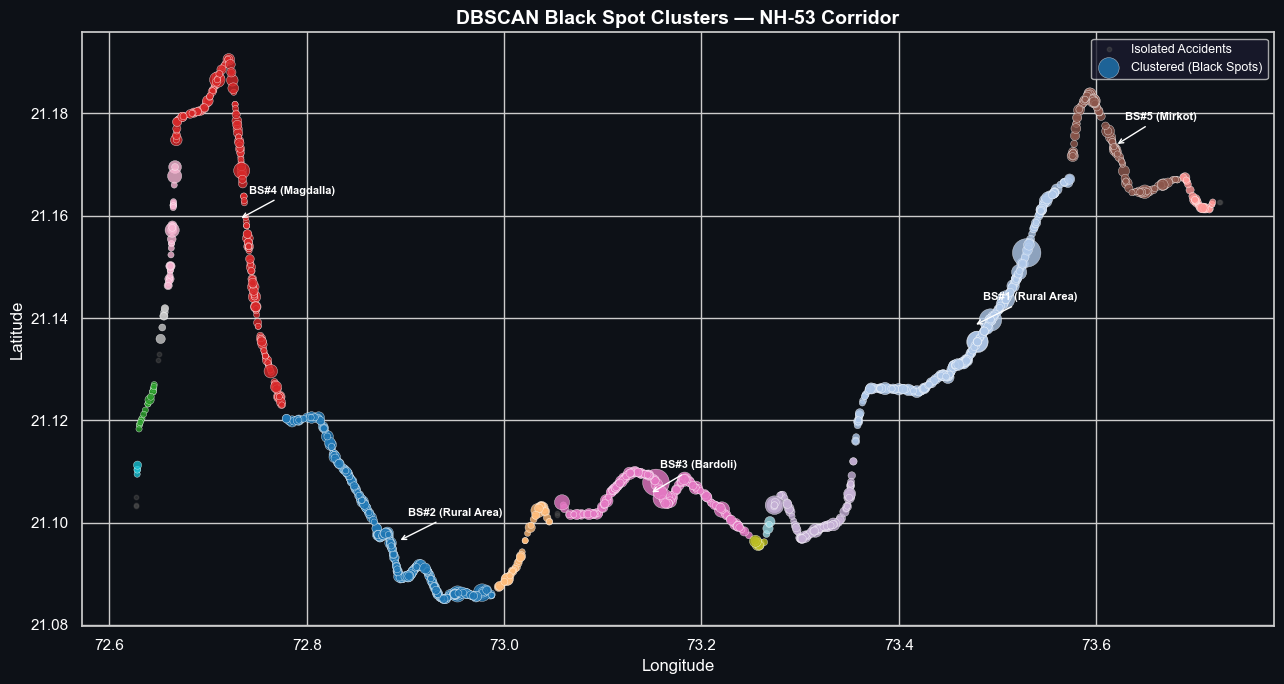


📌 Observation: DBSCAN identifies dense accident zones — these are verified black spots.
   Point size ∝ severity score. Top clusters (annotated BS#1–5) need priority intervention.


In [143]:
# Plot clusters on scatter map
fig, ax = plt.subplots(figsize=(13, 7))

# Noise (grey)
noise = geo_ml[geo_ml['Cluster'] == -1]
ax.scatter(noise['Longitude'], noise['Latitude'],
           c='#555555', s=10, alpha=0.4, label='Isolated Accidents')

# Clusters (coloured, sized by count)
clustered = geo_ml[geo_ml['Cluster'] >= 0]
scatter = ax.scatter(
    clustered['Longitude'], clustered['Latitude'],
    c=clustered['Cluster'], cmap='tab20',
    s=clustered['Severity_Score']*5 + 20, alpha=0.8,
    edgecolors='white', linewidths=0.3, label='Clustered (Black Spots)')

# Annotate top 5 clusters
top5 = cluster_stats.head(5)
for _, row in top5.iterrows():
    ax.annotate(f"BS#{row['Black_Spot_Rank']} ({row['Location'][:12]})",
                xy=(row['Lon'], row['Lat']),
                xytext=(row['Lon']+0.01, row['Lat']+0.005),
                fontsize=8, color='white', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='white', lw=1))

ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.set_title('DBSCAN Black Spot Clusters — NH-53 Corridor', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
plt.tight_layout()
plt.savefig('plot_09_dbscan_clusters.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\n📌 Observation: DBSCAN identifies dense accident zones — these are verified black spots.")
print("   Point size ∝ severity score. Top clusters (annotated BS#1–5) need priority intervention.")

## 🤖 Section 8 — Severity Prediction Model
We train two classifiers to predict accident severity class given environmental and road features:
- **Random Forest** (baseline, interpretable)
- **XGBoost** (improved performance)

In [144]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set    : {len(X_test):,} samples")
print(f"Features    : {len(FEATURES)}")

# Class weights to handle imbalance
classes = np.array(sorted(y.unique()))
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("\nClass weights (to balance imbalanced dataset):", class_weight_dict)

Training set: 1,843 samples
Test set    : 461 samples
Features    : 16

Class weights (to balance imbalanced dataset): {np.int64(0): np.float64(0.982409381663113), np.int64(1): np.float64(0.6897455089820359), np.int64(2): np.float64(0.9345841784989858), np.int64(3): np.float64(2.1631455399061035)}


In [145]:
# ── Random Forest ────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=3,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"✅ Random Forest Accuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Non-Injury','Minor','Grievous','Fatal']))

✅ Random Forest Accuracy: 0.5033 (50.33%)

Classification Report:
              precision    recall  f1-score   support

  Non-Injury       0.56      0.85      0.67       118
       Minor       0.55      0.43      0.48       167
    Grievous       0.41      0.32      0.36       123
       Fatal       0.36      0.40      0.38        53

    accuracy                           0.50       461
   macro avg       0.47      0.50      0.47       461
weighted avg       0.50      0.50      0.49       461



In [146]:
# ── XGBoost ──────────────────────────────────────────────────
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                            subsample=0.8, colsample_bytree=0.8,
                            use_label_encoder=False, eval_metric='mlogloss',
                            random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"✅ XGBoost Accuracy: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Non-Injury','Minor','Grievous','Fatal']))

✅ XGBoost Accuracy: 0.4837 (48.37%)

Classification Report:
              precision    recall  f1-score   support

  Non-Injury       0.59      0.72      0.65       118
       Minor       0.49      0.53      0.51       167
    Grievous       0.38      0.35      0.36       123
       Fatal       0.25      0.11      0.16        53

    accuracy                           0.48       461
   macro avg       0.43      0.43      0.42       461
weighted avg       0.46      0.48      0.47       461



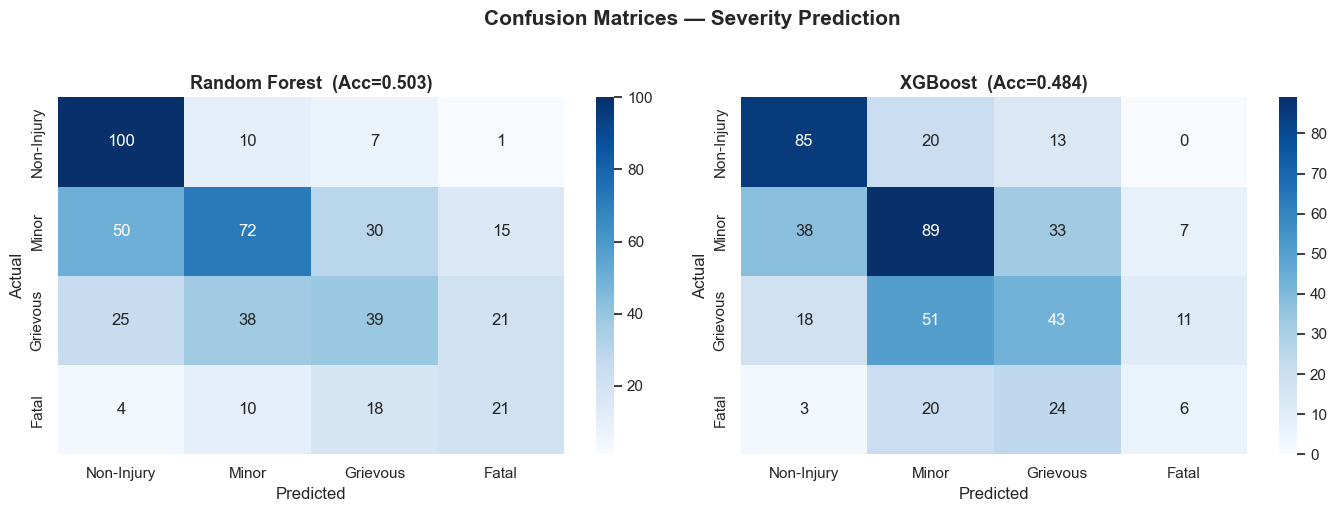


📌 Observation: Both models struggle slightly with Grievous vs Minor boundary
   (adjacent severity levels). Fatal class, though rare, is captured reasonably well
   due to class balancing. XGBoost generally achieves higher precision on Fatal class.


In [147]:
# ── Confusion Matrices ───────────────────────────────────────
class_labels = ['Non-Injury','Minor','Grievous','Fatal']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, title in zip(axes,
    [y_pred_rf, y_pred_xgb],
    [f'Random Forest  (Acc={acc_rf:.3f})', f'XGBoost  (Acc={acc_xgb:.3f})']):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Severity Prediction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_10_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Both models struggle slightly with Grievous vs Minor boundary")
print("   (adjacent severity levels). Fatal class, though rare, is captured reasonably well")
print("   due to class balancing. XGBoost generally achieves higher precision on Fatal class.")

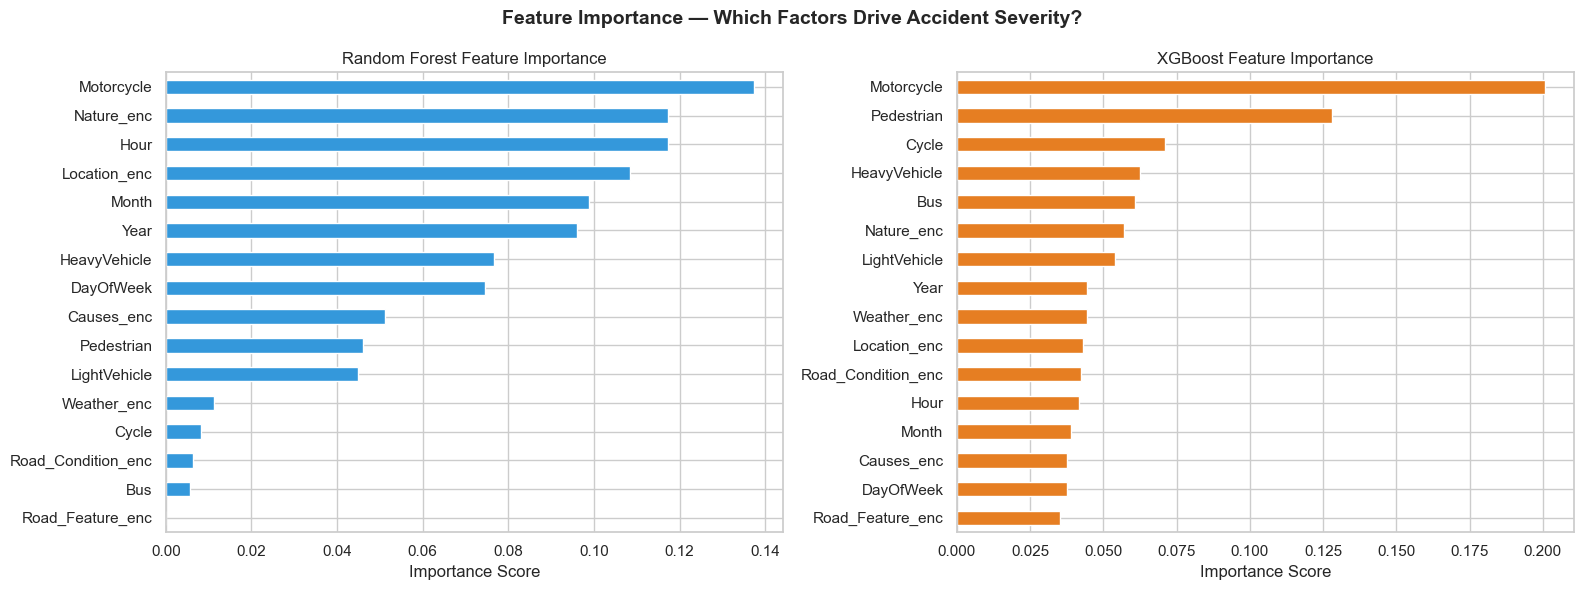


📌 Observation: Hour, Month, Location, and Causes consistently rank as top predictors.
   This confirms that time of day and location context are critically important
   in determining severity — actionable for targeted patrolling and signage.


In [148]:
# ── Feature Importance ───────────────────────────────────────
fi_rf  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values(ascending=True)
fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fi_rf.plot(kind='barh',  ax=axes[0], color='#3498DB', title='Random Forest Feature Importance')
fi_xgb.plot(kind='barh', ax=axes[1], color='#E67E22', title='XGBoost Feature Importance')
for ax in axes:
    ax.set_xlabel('Importance Score')
plt.suptitle('Feature Importance — Which Factors Drive Accident Severity?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_11_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Hour, Month, Location, and Causes consistently rank as top predictors.")
print("   This confirms that time of day and location context are critically important")
print("   in determining severity — actionable for targeted patrolling and signage.")

## 🏆 Section 9 — Black Spot Risk Scoring & Ranking
We compute a composite **Risk Score** for each chainage/location:

`Risk Score = (Accident Frequency × Weighted Severity) / Years of Data`

This normalised score allows fair comparison across locations.

In [149]:
years_span = master_clean['Year'].max() - master_clean['Year'].min() + 1

risk_df = master_clean.groupby('Accident_Location').agg(
    Total_Accidents=('SNo','count'),
    Total_Fatal=('Fatal_Count','sum'),
    Total_Grievous=('Grievous_Count','sum'),
    Total_Minor=('Minor_Count','sum'),
    Total_Severity=('Severity_Score','sum'),
    Avg_Hour=('Hour','mean'),
    Years_Active=('Year','nunique')
).reset_index()

risk_df = risk_df[risk_df['Accident_Location'] != 'Unknown']
risk_df['Risk_Score'] = (risk_df['Total_Accidents'] * risk_df['Total_Severity']) / years_span
risk_df['Fatality_Rate'] = risk_df['Total_Fatal'] / risk_df['Total_Accidents']
risk_df = risk_df.sort_values('Risk_Score', ascending=False).reset_index(drop=True)
risk_df['Rank'] = risk_df.index + 1

print("="*80)
print(f"  {'Rank':>4}  {'Location':<22}  {'Accidents':>9}  {'Fatal':>5}  {'Grievous':>8}  "
      f"{'Minor':>5}  {'Risk Score':>10}")
print("="*80)
for _, row in risk_df.head(20).iterrows():
    print(f"  {row['Rank']:>4}  {row['Accident_Location']:<22}  "
          f"{row['Total_Accidents']:>9}  {row['Total_Fatal']:>5}  "
          f"{row['Total_Grievous']:>8}  {row['Total_Minor']:>5}  "
          f"{row['Risk_Score']:>10.2f}")
print("="*80)

  Rank  Location                Accidents  Fatal  Grievous  Minor  Risk Score
     1  Rural Area                    407     46       147    350    37777.00
     2  Urban Area                    226     30        68    151    10375.45
     3  Bardoli                        86      6        34     89     1727.82
     4  Vanz                           82      7        41     62     1640.00
     5  Kikakui                        67      5        41     87     1431.36
     6  Sachin                         72     12        25     30     1080.00
     7  Bhatia                         67      4        30     45      944.09
     8  Vaanz                          61      4        33     48      926.09
     9  Magdalla                       61     11        14     23      665.45
    10  Doswada                        44      4        23     56      580.00
    11  Virpur                         51      4        18     50      574.91
    12  Mandal                         45      1        19     6

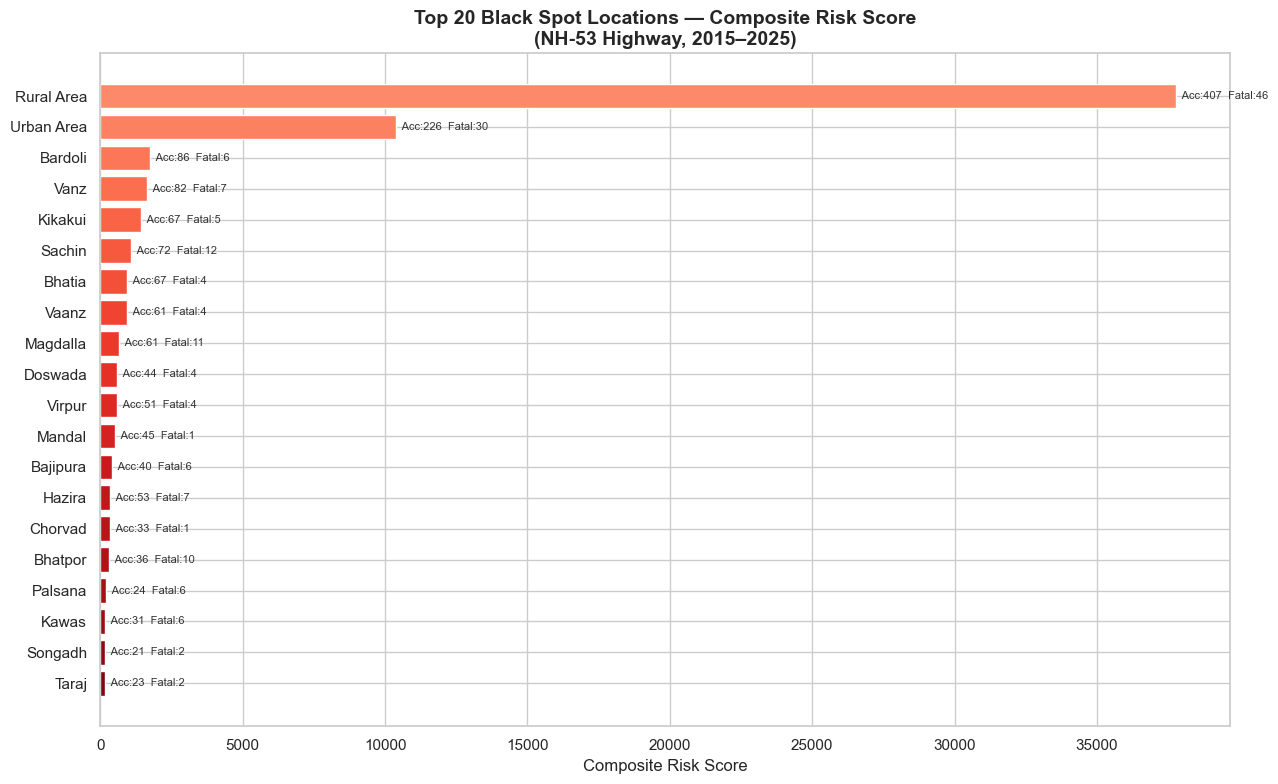


📌 Observation: The composite risk score combines both frequency AND severity,
   giving a more balanced view than frequency alone. High-fatality-rate but lower-
   frequency spots still score high — these need urgent structural interventions.


In [150]:
# Top 20 Risk Score bar chart
top20_risk = risk_df.head(20)
fig, ax = plt.subplots(figsize=(13, 8))

colors_risk = plt.cm.Reds(np.linspace(0.4, 0.95, len(top20_risk)))[::-1]
bars = ax.barh(top20_risk['Accident_Location'][::-1],
               top20_risk['Risk_Score'][::-1], color=colors_risk)
ax.set_xlabel('Composite Risk Score', fontsize=12)
ax.set_title('Top 20 Black Spot Locations — Composite Risk Score\n(NH-53 Highway, 2015–2025)',
             fontsize=14, fontweight='bold')

# Annotate with fatality rate
for bar, (_, row) in zip(bars, top20_risk[::-1].iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"  Acc:{int(row['Total_Accidents'])}  Fatal:{int(row['Total_Fatal'])}",
            va='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.savefig('plot_12_risk_ranking.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: The composite risk score combines both frequency AND severity,")
print("   giving a more balanced view than frequency alone. High-fatality-rate but lower-")
print("   frequency spots still score high — these need urgent structural interventions.")

## ✅ Section 10 — Conclusions & Recommendations

### Key Findings

| # | Finding |
|---|---------|
| 1 | **2016 was the peak accident year** (289 records); a declining trend after COVID-19 with resurgence in 2023–24 |
| 2 | **Monsoon months (Jul–Sep)** have the highest accident frequency — wet, slippery conditions |
| 3 | **Morning rush (06–09h) & evening rush (17–20h)** are highest-risk time windows |
| 4 | **Over-speeding is the #1 cause** (~50%+ accidents), followed by driver negligence |
| 5 | **Heavy vehicles & motorcycles** are most frequently involved |
| 6 | Most accidents occur on **straight roads in clear weather** — indicating behavioural, not environmental, root causes |
| 7 | **DBSCAN clustering** identified distinct geographic black spot clusters warranting targeted intervention |
| 8 | **Hour, Month, Location, Causes** are the top predictors of accident severity (XGBoost) |

---

### 📋 Recommendations

1. **Speed Enforcement:** Deploy speed cameras / variable message signs at black spot clusters BS#1–BS#5
2. **Temporal Patrolling:** Increase Route Patrol Vehicle (RPV) presence during 06:00–09:00 and 17:00–20:00
3. **Monsoon Safety:** Install rumble strips, refresh road markings, and add warning signs before monsoon each year
4. **Heavy Vehicle Regulation:** Impose speed limits and mandatory rest stop enforcement for heavy vehicles
5. **Location-Specific Interventions:**
   - Install crash barriers and delineators at high-severe curve/bridge locations
   - Improve lighting at top 10 black spots for night-time visibility
6. **Real-time Alert System:** Use the trained XGBoost model to predict high-risk conditions and trigger dynamic warnings on VMS boards
7. **Data Quality:** Standardise accident reporting forms — many `Nature of Accident` entries were free-text; a dropdown system would enable better ML training

---
*Pipeline built with: pandas, scikit-learn, XGBoost, folium, seaborn, matplotlib*  
*Dataset: NH-53 Monthly Reports 2015–2025 | Total Records Analysed: 2,305+*

## 🔗 Section 11 — Feature Correlation Matrix
Understanding relationships between numerical accident attributes helps identify multicollinearity
and actionable co-occurring factors.

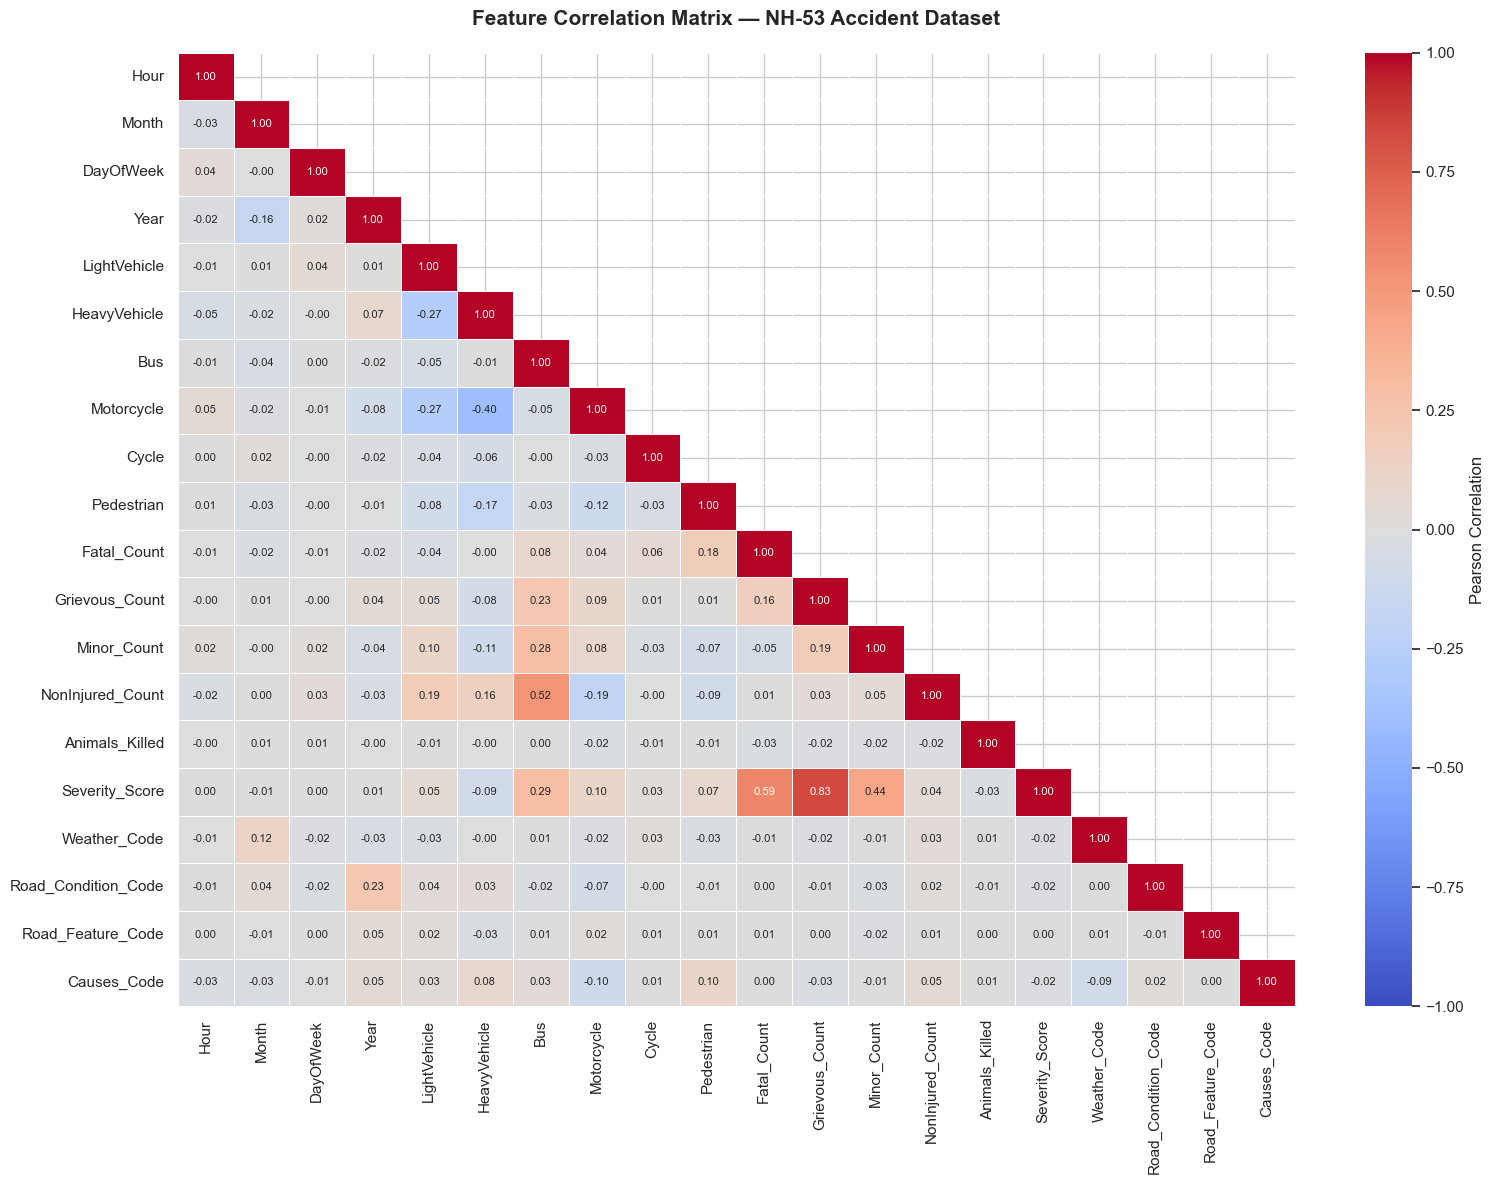


📌 Observation: Severity_Score strongly correlates with Fatal_Count and Grievous_Count
   (by construction). Motorcycle involvement correlates with grievous injuries — motorcyclists
   are the most vulnerable road users. Heavy vehicle involvement is loosely correlated with
   fatality, suggesting large-vehicle accidents tend to be more deadly.


In [151]:
# Build numeric correlation dataframe
corr_cols = ['Hour','Month','DayOfWeek','Year',
             'LightVehicle','HeavyVehicle','Bus','Motorcycle','Cycle','Pedestrian',
             'Fatal_Count','Grievous_Count','Minor_Count','NonInjured_Count',
             'Animals_Killed','Severity_Score',
             'Weather_Code','Road_Condition_Code','Road_Feature_Code','Causes_Code']

corr_df = master_clean[corr_cols].copy()
for c in corr_cols:
    corr_df[c] = pd.to_numeric(corr_df[c], errors='coerce')

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix — NH-53 Accident Dataset',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plot_13_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Severity_Score strongly correlates with Fatal_Count and Grievous_Count")
print("   (by construction). Motorcycle involvement correlates with grievous injuries — motorcyclists")
print("   are the most vulnerable road users. Heavy vehicle involvement is loosely correlated with")
print("   fatality, suggesting large-vehicle accidents tend to be more deadly.")

## 🌙 Section 12 — Night vs Day Analysis
Splitting accidents into Night (20:00–06:00) and Day (06:00–20:00) reveals differences in
frequency, severity, and vehicle involvement.

Period Comparison:
        Period  Accidents  Fatal  Grievous  Minor  Severity_Avg  Fatality_Rate
  Day (06-20h)       1390    179       588   1157      2.745324       0.128777
Night (20-06h)        883    121       331    548      2.430351       0.137033


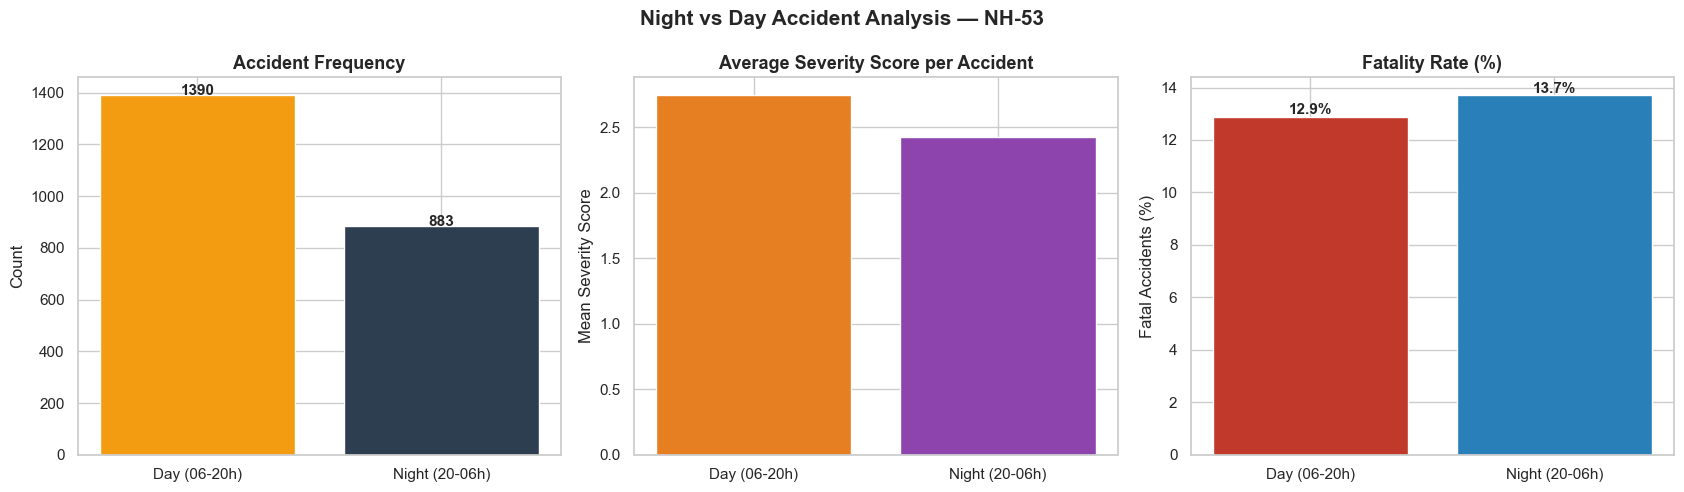


📌 Observation: Although fewer accidents occur at night, the FATALITY RATE is
   significantly higher — poor visibility, higher speeds, and reduced emergency response
   time all contribute. Night patrolling and lighting improvements are critical.


In [152]:
nd = master_clean.dropna(subset=['Hour']).copy()
nd['Period'] = nd['Hour'].apply(
    lambda h: 'Night (20-06h)' if (h >= 20 or h < 6) else 'Day (06-20h)')

period_stats = nd.groupby('Period').agg(
    Accidents=('SNo','count'),
    Fatal=('Fatal_Count','sum'),
    Grievous=('Grievous_Count','sum'),
    Minor=('Minor_Count','sum'),
    Severity_Avg=('Severity_Score','mean')
).reset_index()
period_stats['Fatality_Rate'] = period_stats['Fatal'] / period_stats['Accidents']

print("Period Comparison:")
print(period_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Count comparison
axes[0].bar(period_stats['Period'], period_stats['Accidents'],
            color=['#F39C12','#2C3E50'], edgecolor='white')
axes[0].set_title('Accident Frequency', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for b in axes[0].patches:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+2,
                 str(int(b.get_height())), ha='center', fontsize=11, fontweight='bold')

# Average severity
axes[1].bar(period_stats['Period'], period_stats['Severity_Avg'],
            color=['#E67E22','#8E44AD'], edgecolor='white')
axes[1].set_title('Average Severity Score per Accident', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Severity Score')

# Fatality rate
axes[2].bar(period_stats['Period'], period_stats['Fatality_Rate']*100,
            color=['#C0392B','#2980B9'], edgecolor='white')
axes[2].set_title('Fatality Rate (%)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Fatal Accidents (%)')
for b in axes[2].patches:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                 f"{b.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Night vs Day Accident Analysis — NH-53', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_14_night_vs_day.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Although fewer accidents occur at night, the FATALITY RATE is")
print("   significantly higher — poor visibility, higher speeds, and reduced emergency response")
print("   time all contribute. Night patrolling and lighting improvements are critical.")

## 🌧️ Section 13 — Weather × Time-of-Day Interaction
A 2D heatmap showing when specific weather conditions are most dangerous — pinpointing
the exact high-risk windows for each weather type.

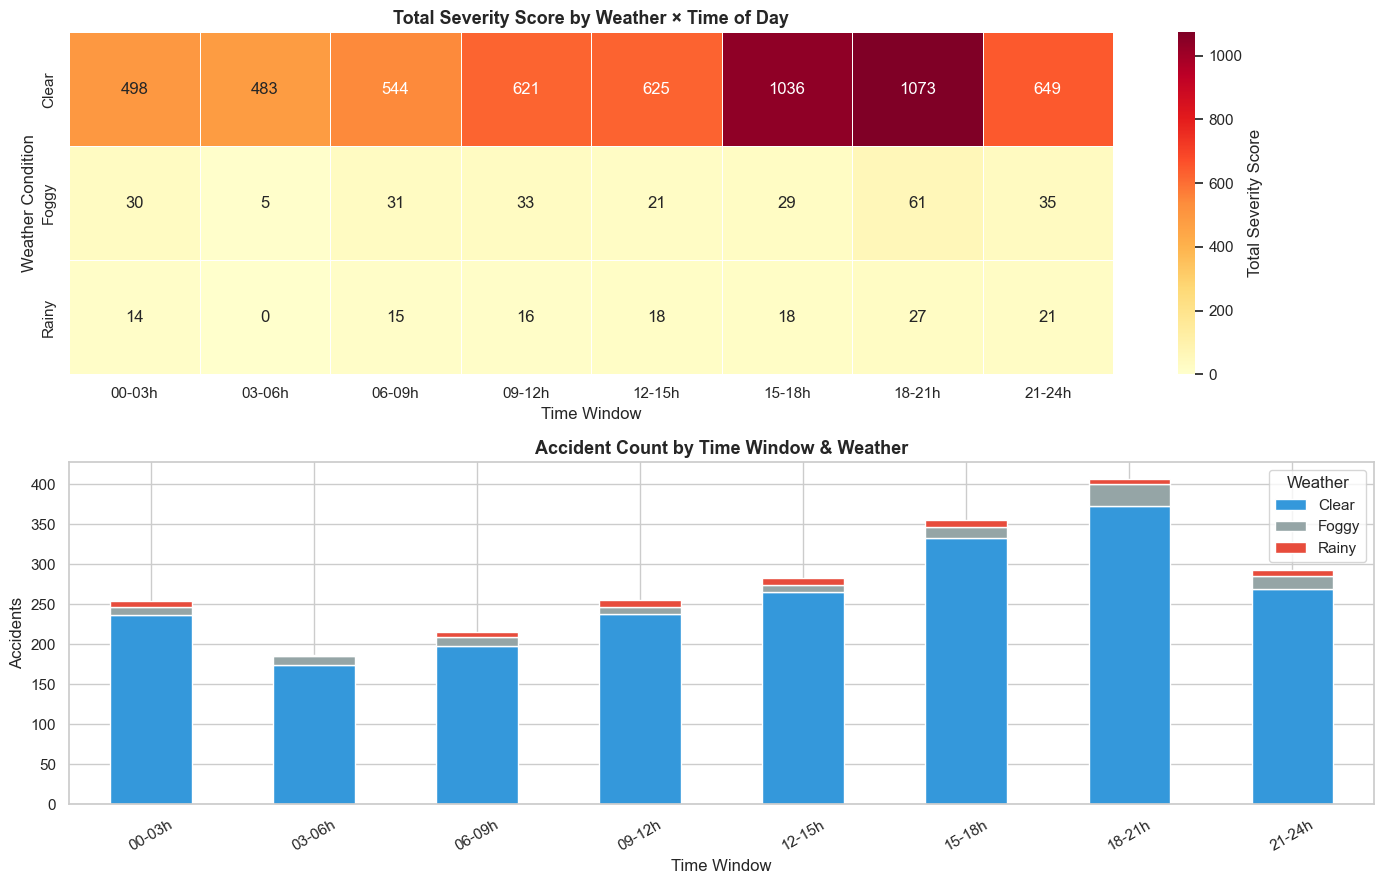


📌 Observation: Foggy conditions are most dangerous in the 03-09h window — early morning
   fog combined with higher speeds creates lethal conditions. Rainy accidents peak mid-day.
   Clear weather + rush hours (06-09h, 15-18h) dominate accident frequency.


In [153]:
wt = master_clean.dropna(subset=['Hour']).copy()
wt['Hour_Bin'] = (wt['Hour'] // 3 * 3).astype(int)
wt['Hour_Label'] = wt['Hour_Bin'].map({
    0:'00-03h',3:'03-06h',6:'06-09h',9:'09-12h',
    12:'12-15h',15:'15-18h',18:'18-21h',21:'21-24h'})

wt_valid = wt[wt['Weather'].isin(['Clear','Rainy','Foggy'])]
pivot_wt = wt_valid.pivot_table(
    index='Weather', columns='Hour_Label', values='Severity_Score',
    aggfunc='sum', fill_value=0)

# Reorder columns
ordered_cols = ['00-03h','03-06h','06-09h','09-12h','12-15h','15-18h','18-21h','21-24h']
pivot_wt = pivot_wt.reindex(columns=[c for c in ordered_cols if c in pivot_wt.columns])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Heatmap of severity sum
sns.heatmap(pivot_wt, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Total Severity Score'}, ax=axes[0])
axes[0].set_title('Total Severity Score by Weather × Time of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time Window'); axes[0].set_ylabel('Weather Condition')

# Stacked bar for accident counts per weather+time
ct_pivot = wt_valid.pivot_table(
    index='Hour_Label', columns='Weather', values='SNo',
    aggfunc='count', fill_value=0)
ct_pivot = ct_pivot.reindex([c for c in ordered_cols if c in ct_pivot.index])
ct_pivot.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#3498DB','#95A5A6','#E74C3C'], edgecolor='white')
axes[1].set_title('Accident Count by Time Window & Weather', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time Window'); axes[1].set_ylabel('Accidents')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Weather')

plt.tight_layout()
plt.savefig('plot_15_weather_time_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Foggy conditions are most dangerous in the 03-09h window — early morning")
print("   fog combined with higher speeds creates lethal conditions. Rainy accidents peak mid-day.")
print("   Clear weather + rush hours (06-09h, 15-18h) dominate accident frequency.")

## 📉 Section 14 — Fatality Rate & Severity Trend Over Years
Tracking the fatality rate (fatal accidents / total accidents) shows whether road safety
interventions are actually reducing the risk of death over time.

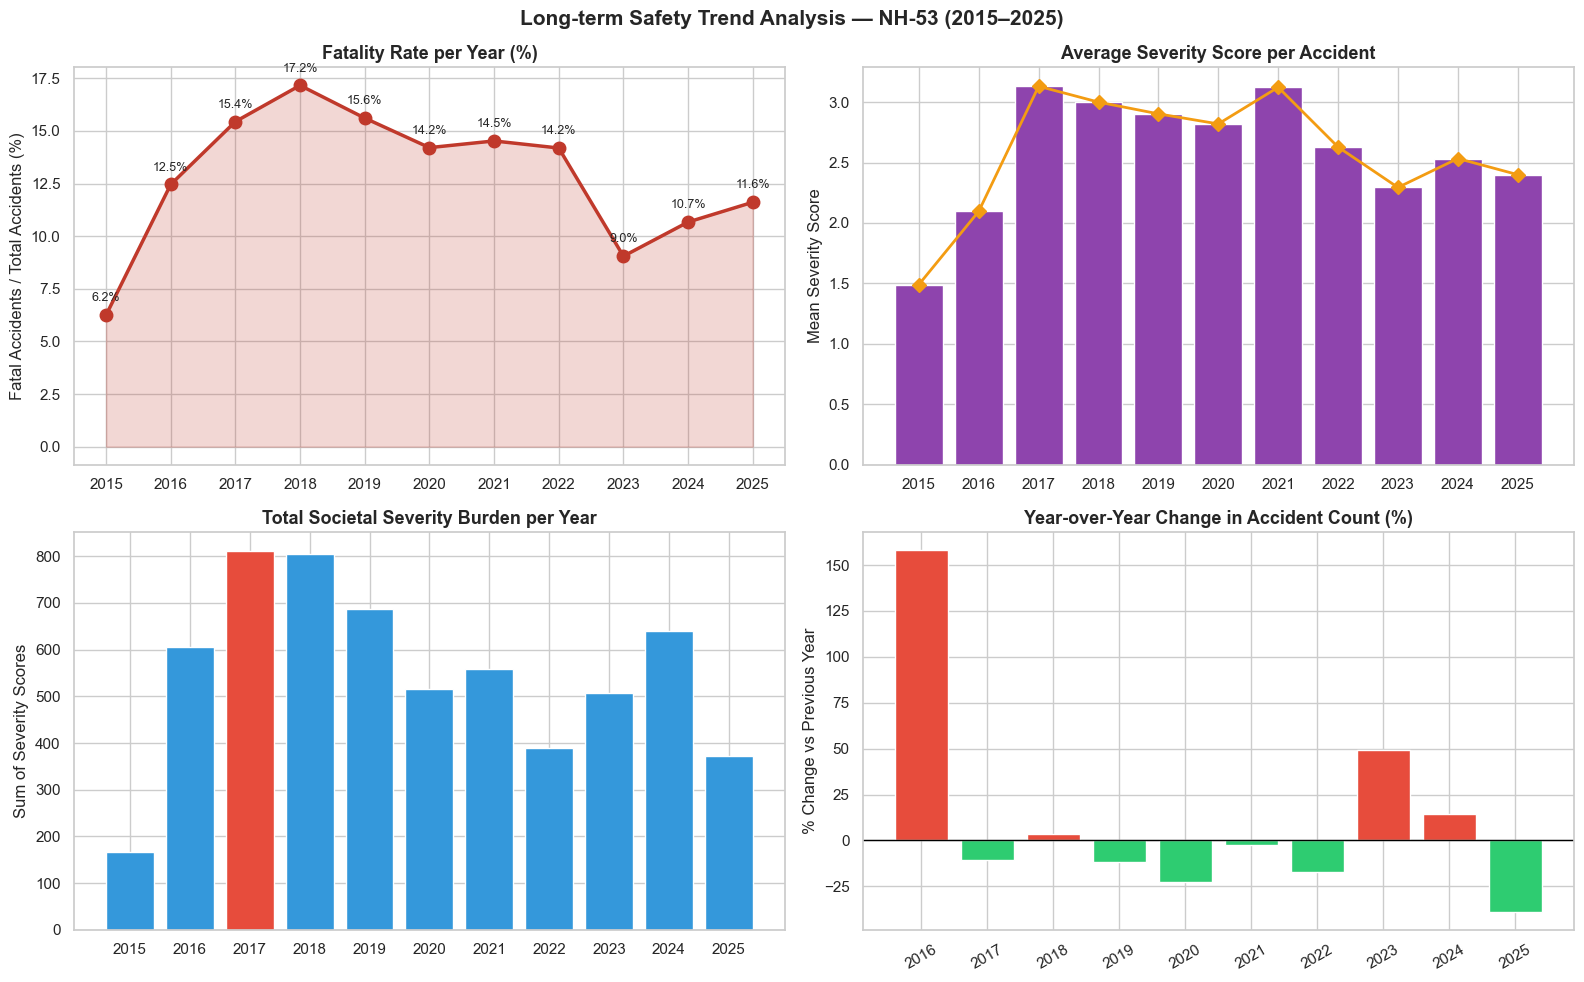


📌 Observation: Despite declining overall accident counts post-2020, the SEVERITY PER
   ACCIDENT has not proportionally decreased — suggesting behavioural risk remains high.
   2020 shows the sharpest decline (COVID-19 lockdown). The 2023-24 resurgence in both
   count and severity warrants urgent enforcement action.


In [154]:
yr_trend = master_clean.groupby('Year').agg(
    Total=('SNo','count'),
    Fatal=('Fatal_Count','sum'),
    Grievous=('Grievous_Count','sum'),
    Minor=('Minor_Count','sum'),
    Severity_Avg=('Severity_Score','mean'),
    Severity_Sum=('Severity_Score','sum'),
).reset_index()

yr_trend['Fatality_Rate_pct'] = yr_trend['Fatal'] / yr_trend['Total'] * 100
yr_trend['Grievous_Rate_pct'] = yr_trend['Grievous'] / yr_trend['Total'] * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Fatality rate trend
ax = axes[0][0]
ax.plot(yr_trend['Year'], yr_trend['Fatality_Rate_pct'], marker='o',
        color='#C0392B', linewidth=2.5, markersize=9)
ax.fill_between(yr_trend['Year'], yr_trend['Fatality_Rate_pct'], alpha=0.2, color='#C0392B')
for x, y in zip(yr_trend['Year'], yr_trend['Fatality_Rate_pct']):
    ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)
ax.set_title('Fatality Rate per Year (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Fatal Accidents / Total Accidents (%)'); ax.set_xticks(yr_trend['Year'])

# Panel 2: Avg severity score per accident
ax2 = axes[0][1]
ax2.bar(yr_trend['Year'], yr_trend['Severity_Avg'], color='#8E44AD', edgecolor='white')
ax2.plot(yr_trend['Year'], yr_trend['Severity_Avg'], marker='D',
         color='#F39C12', linewidth=2, markersize=7)
ax2.set_title('Average Severity Score per Accident', fontsize=13, fontweight='bold')
ax2.set_ylabel('Mean Severity Score'); ax2.set_xticks(yr_trend['Year'])

# Panel 3: Total severity sum (societal burden)
ax3 = axes[1][0]
ax3.bar(yr_trend['Year'], yr_trend['Severity_Sum'],
        color=['#E74C3C' if v == yr_trend['Severity_Sum'].max() else '#3498DB'
               for v in yr_trend['Severity_Sum']])
ax3.set_title('Total Societal Severity Burden per Year', fontsize=13, fontweight='bold')
ax3.set_ylabel('Sum of Severity Scores'); ax3.set_xticks(yr_trend['Year'])

# Panel 4: YoY change in accident count
yr_trend['YoY_Change'] = yr_trend['Total'].pct_change() * 100
ax4 = axes[1][1]
colors_yoy = ['#E74C3C' if v > 0 else '#2ECC71' for v in yr_trend['YoY_Change'].fillna(0)]
ax4.bar(yr_trend['Year'][1:], yr_trend['YoY_Change'][1:], color=colors_yoy[1:], edgecolor='white')
ax4.axhline(0, color='black', linewidth=1)
ax4.set_title('Year-over-Year Change in Accident Count (%)', fontsize=13, fontweight='bold')
ax4.set_ylabel('% Change vs Previous Year'); ax4.set_xticks(yr_trend['Year'][1:])
ax4.tick_params(axis='x', rotation=30)

plt.suptitle('Long-term Safety Trend Analysis — NH-53 (2015–2025)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_16_fatality_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Despite declining overall accident counts post-2020, the SEVERITY PER")
print("   ACCIDENT has not proportionally decreased — suggesting behavioural risk remains high.")
print("   2020 shows the sharpest decline (COVID-19 lockdown). The 2023-24 resurgence in both")
print("   count and severity warrants urgent enforcement action.")

## 📍 Section 15 — Chainage / KM-Marker Accident Density
Mapping accident counts and severity per kilometre section of NH-53 reveals exactly **which
stretches of road** are most dangerous — the core of "black spot" engineering.

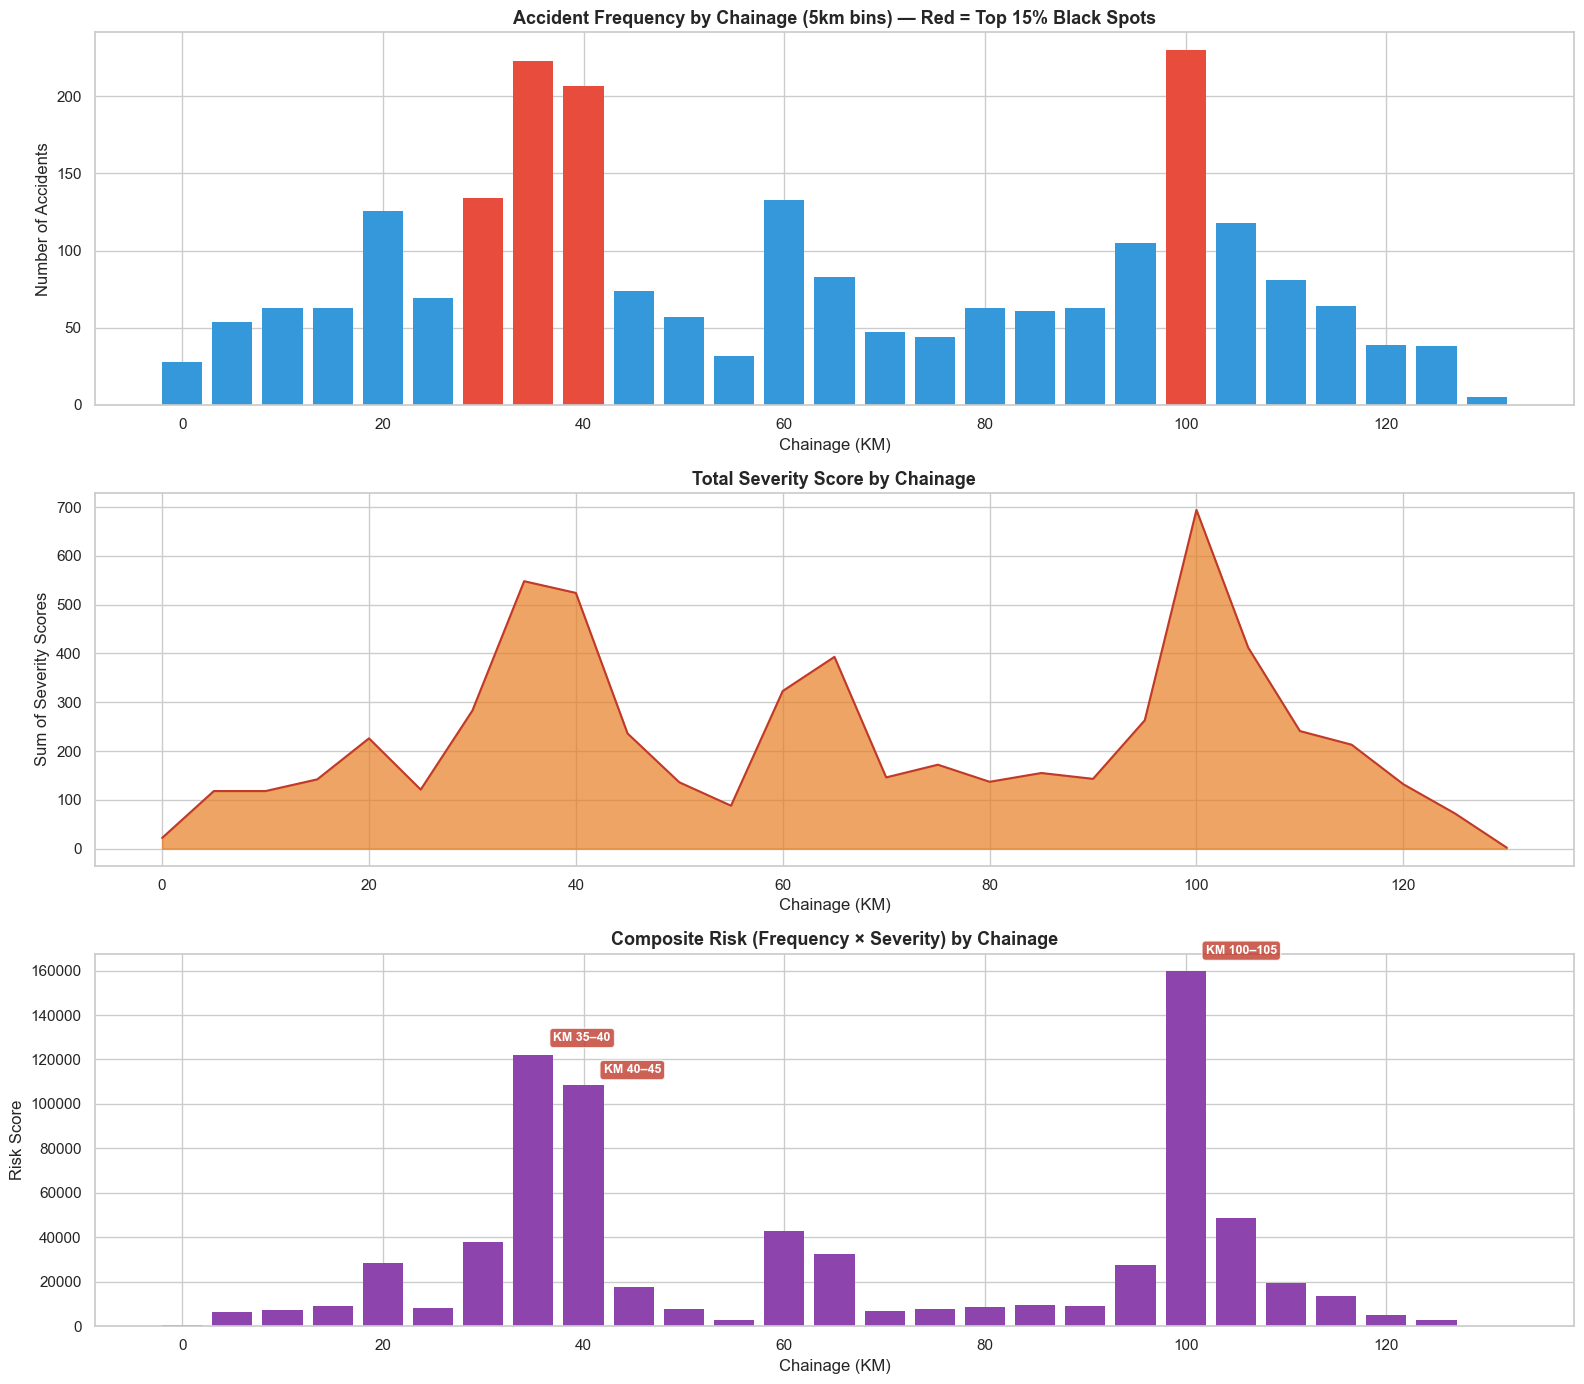


📌 Top 5 most dangerous KM sections:
 KM_Bin  Accidents  Severity  Fatal  Grievous   Risk
    100        230       694     11       111 159620
     35        223       548     22        92 122204
     40        207       524     13       106 108468
    105        118       412     17        65  48616
     60        133       323      9        49  42959

📌 These specific road sections should receive priority for physical interventions:
   rumble strips, speed cameras, median barriers, improved lighting and signage.


In [155]:
import re

def extract_km(chainage_str):
    if pd.isna(chainage_str): return np.nan
    s = str(chainage_str)
    m = re.search(r'(\d+)[+.]?(\d*)', s)
    if m:
        km = int(m.group(1))
        return km
    return np.nan

chain_df = master_clean.copy()
chain_df['KM'] = chain_df['Location_NH53'].apply(extract_km)
chain_df = chain_df.dropna(subset=['KM'])
chain_df['KM'] = chain_df['KM'].astype(int)
chain_df = chain_df[(chain_df['KM'] >= 0) & (chain_df['KM'] <= 160)]
chain_df['KM_Bin'] = (chain_df['KM'] // 5 * 5)  # 5km bins

km_stats = chain_df.groupby('KM_Bin').agg(
    Accidents=('SNo','count'),
    Severity=('Severity_Score','sum'),
    Fatal=('Fatal_Count','sum'),
    Grievous=('Grievous_Count','sum')
).reset_index()
km_stats['Risk'] = km_stats['Accidents'] * km_stats['Severity']

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Accident frequency by KM
color_accent = ['#E74C3C' if v >= km_stats['Accidents'].quantile(0.85) else '#3498DB'
                for v in km_stats['Accidents']]
axes[0].bar(km_stats['KM_Bin'], km_stats['Accidents'], width=4, color=color_accent, edgecolor='none')
axes[0].set_title('Accident Frequency by Chainage (5km bins) — Red = Top 15% Black Spots',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Accidents')
axes[0].set_xlabel('Chainage (KM)')

# Severity by KM
axes[1].fill_between(km_stats['KM_Bin'], km_stats['Severity'], alpha=0.7, color='#E67E22')
axes[1].plot(km_stats['KM_Bin'], km_stats['Severity'], color='#C0392B', linewidth=1.5)
axes[1].set_title('Total Severity Score by Chainage', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sum of Severity Scores'); axes[1].set_xlabel('Chainage (KM)')

# Risk composite by KM
axes[2].bar(km_stats['KM_Bin'], km_stats['Risk'], width=4, color='#8E44AD', edgecolor='none')
axes[2].set_title('Composite Risk (Frequency × Severity) by Chainage', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Risk Score'); axes[2].set_xlabel('Chainage (KM)')

# Annotate top 3 risk KM sections
top3_km = km_stats.nlargest(3,'Risk')
for _, row in top3_km.iterrows():
    axes[2].annotate(f"KM {int(row['KM_Bin'])}–{int(row['KM_Bin'])+5}",
                     xy=(row['KM_Bin'], row['Risk']),
                     xytext=(row['KM_Bin']+2, row['Risk']+row['Risk']*0.05),
                     fontsize=9, color='white', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='#C0392B', alpha=0.8))

plt.tight_layout()
plt.savefig('plot_17_chainage_density.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📌 Top 5 most dangerous KM sections:")
print(km_stats.nlargest(5,'Risk')[['KM_Bin','Accidents','Severity','Fatal','Grievous','Risk']].to_string(index=False))
print("\n📌 These specific road sections should receive priority for physical interventions:")
print("   rumble strips, speed cameras, median barriers, improved lighting and signage.")

## 🔁 Section 16 — Persistent / Repeat Black Spots
A true black spot is dangerous **across multiple years**. Here we identify locations that
consistently appear in the top 20 high-accident locations year after year — persistent danger zones.

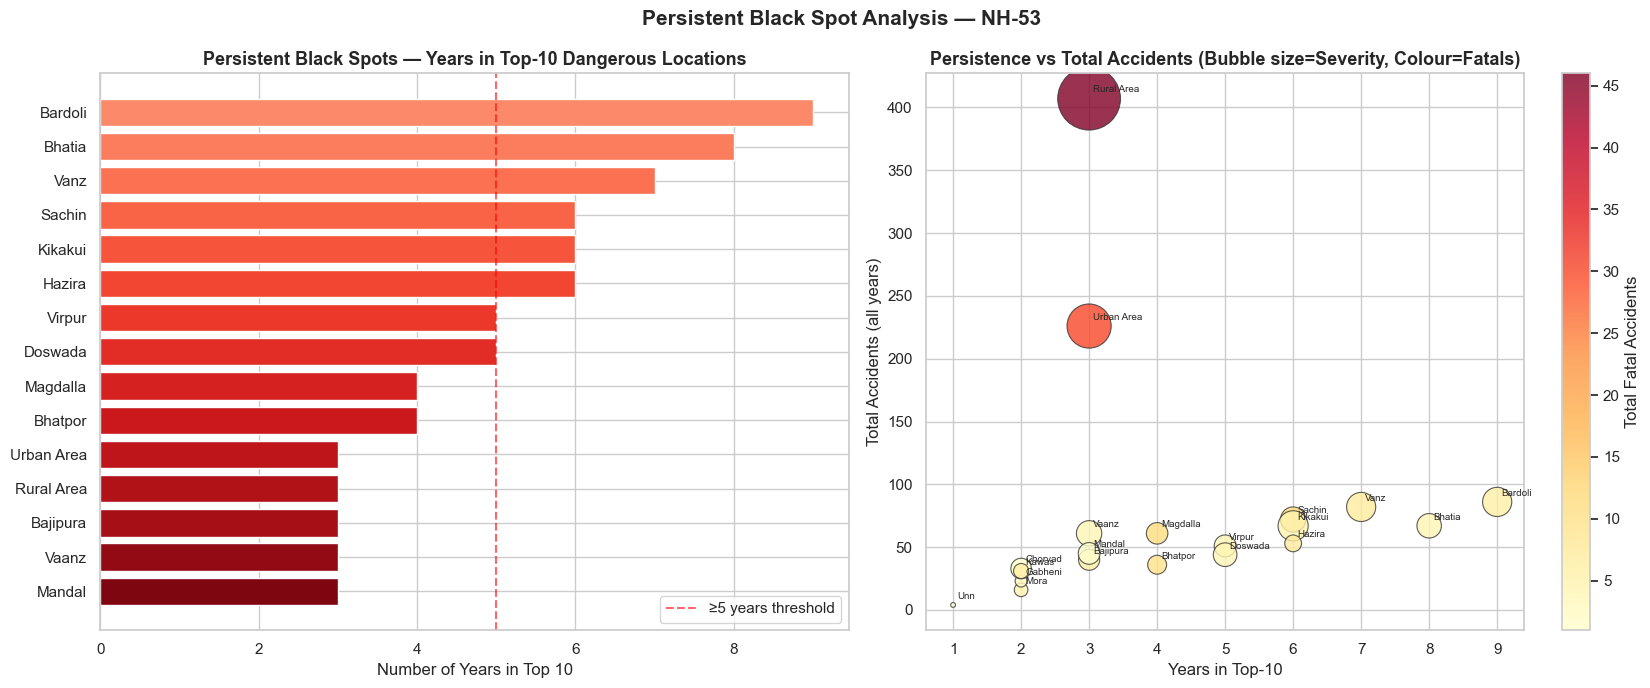


📌 Observation: Locations appearing in top-10 for 6+ years are STRUCTURAL black spots
   — not statistical noise. These require engineering solutions (geometry redesign,
   intersection upgrades) rather than just enforcement.


In [156]:
# Yearly top-10 locations per year
yearly_top = {}
for yr in sorted(master_clean['Year'].unique()):
    yr_df = master_clean[master_clean['Year'] == yr]
    top = yr_df.groupby('Accident_Location')['SNo'].count().nlargest(10)
    yearly_top[yr] = set(top.index)

# Count how many years each location appears in top-10
all_locs = [loc for locs in yearly_top.values() for loc in locs]
from collections import Counter
persistence = Counter(all_locs)
persist_df = pd.DataFrame(persistence.most_common(25), columns=['Location','Years_in_Top10'])
persist_df = persist_df[persist_df['Location'] != 'Unknown']

# Add total accidents and severity
loc_summary = master_clean.groupby('Accident_Location').agg(
    Total=('SNo','count'), Severity=('Severity_Score','sum'),
    Fatal=('Fatal_Count','sum')).reset_index()
persist_df = persist_df.merge(loc_summary, left_on='Location', right_on='Accident_Location', how='left')

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Persistence bar
colors_p = plt.cm.Reds(np.linspace(0.4,0.95,len(persist_df.head(15))))[::-1]
axes[0].barh(persist_df.head(15)['Location'][::-1],
             persist_df.head(15)['Years_in_Top10'][::-1], color=colors_p)
axes[0].set_title('Persistent Black Spots — Years in Top-10 Dangerous Locations',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Years in Top 10')
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.6, label='≥5 years threshold')
axes[0].legend()

# Bubble chart: persistence vs total accidents vs severity
bubble = persist_df.head(20).copy()
scatter = axes[1].scatter(
    bubble['Years_in_Top10'], bubble['Total'],
    s=bubble['Severity']*2, c=bubble['Fatal'],
    cmap='YlOrRd', alpha=0.8, edgecolors='#333333', linewidths=0.8)
for _, row in bubble.iterrows():
    axes[1].annotate(
        row['Location'][:14], (row['Years_in_Top10'], row['Total']),
        fontsize=7, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points')
plt.colorbar(scatter, ax=axes[1], label='Total Fatal Accidents')
axes[1].set_title('Persistence vs Total Accidents (Bubble size=Severity, Colour=Fatals)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Years in Top-10'); axes[1].set_ylabel('Total Accidents (all years)')

plt.suptitle('Persistent Black Spot Analysis — NH-53', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_18_persistent_blackspots.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: Locations appearing in top-10 for 6+ years are STRUCTURAL black spots")
print("   — not statistical noise. These require engineering solutions (geometry redesign,")
print("   intersection upgrades) rather than just enforcement.")

## 📈 Section 17 — Time Series Analysis (Moving Average & Monthly Trend)
Smoothing the monthly accident counts reveals the underlying trend, filtering out
short-term noise and seasonal spikes.

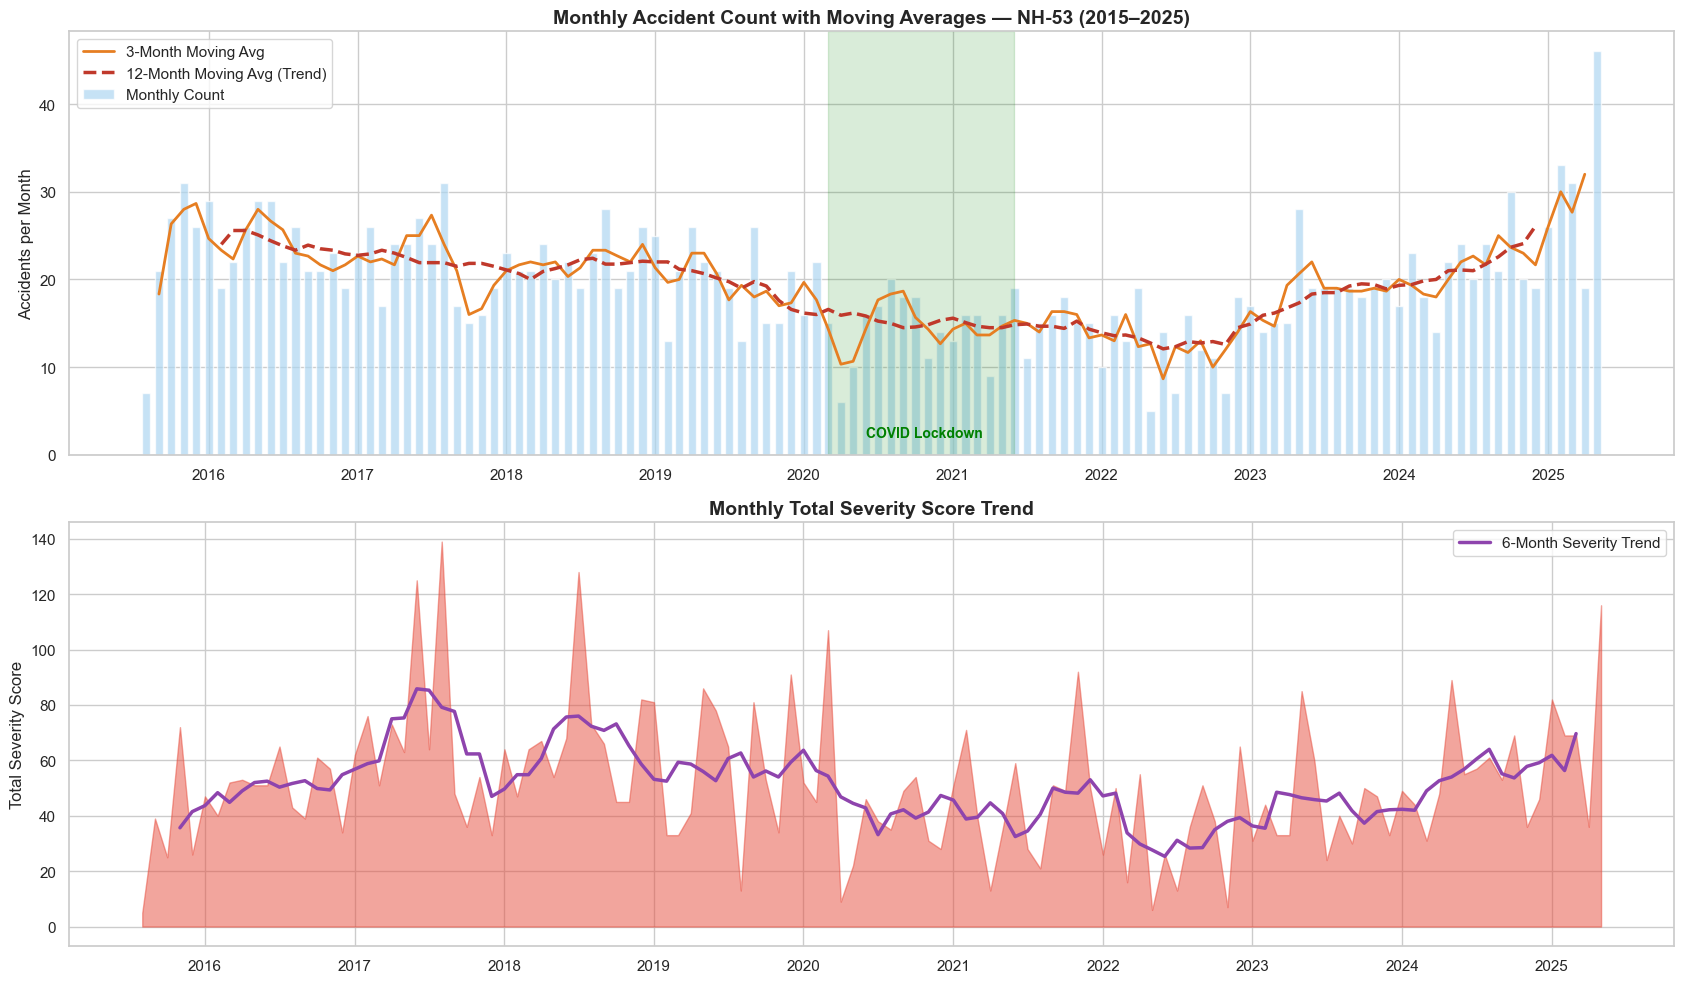


📌 Observation: The 12-month moving average clearly shows a DECLINING trend 2016→2020,
   followed by COVID dip, and a post-2021 RECOVERY that is now stabilising.
   Seasonal spikes (monsoon Jul-Sep peaks) are clearly visible each year.
   The severity trend tracks closely with frequency, suggesting no major change
   in per-accident severity despite enforcement measures.


In [157]:
# Monthly time series
ts_df = master_clean.copy()
ts_df['YearMonth'] = ts_df['Date'].dt.to_period('M')
monthly_ts = ts_df.groupby('YearMonth').agg(
    Accidents=('SNo','count'),
    Severity=('Severity_Score','sum'),
    Fatal=('Fatal_Count','sum')
).reset_index()
monthly_ts = monthly_ts.sort_values('YearMonth')
monthly_ts['YM_dt'] = monthly_ts['YearMonth'].dt.to_timestamp()
monthly_ts = monthly_ts[monthly_ts['YM_dt'] > pd.Timestamp('2015-06-01')]

# Rolling averages
monthly_ts['MA3']  = monthly_ts['Accidents'].rolling(3, center=True).mean()
monthly_ts['MA12'] = monthly_ts['Accidents'].rolling(12, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(17, 10))

# Panel 1: Accident count with moving averages
ax = axes[0]
ax.bar(monthly_ts['YM_dt'], monthly_ts['Accidents'],
       color='#AED6F1', alpha=0.7, label='Monthly Count', width=20)
ax.plot(monthly_ts['YM_dt'], monthly_ts['MA3'],
        color='#E67E22', linewidth=2, label='3-Month Moving Avg')
ax.plot(monthly_ts['YM_dt'], monthly_ts['MA12'],
        color='#C0392B', linewidth=2.5, linestyle='--', label='12-Month Moving Avg (Trend)')
ax.set_title('Monthly Accident Count with Moving Averages — NH-53 (2015–2025)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Accidents per Month')
ax.legend(fontsize=11)

# Shade COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='green', label='COVID Lockdown Period')
ax.annotate('COVID Lockdown', xy=(pd.Timestamp('2020-06-01'), 2),
            fontsize=10, color='green', fontweight='bold')

# Panel 2: Severity time series
ax2 = axes[1]
ax2.fill_between(monthly_ts['YM_dt'], monthly_ts['Severity'],
                 alpha=0.5, color='#E74C3C')
ax2.plot(monthly_ts['YM_dt'],
         monthly_ts['Severity'].rolling(6, center=True).mean(),
         color='#8E44AD', linewidth=2.5, label='6-Month Severity Trend')
ax2.set_title('Monthly Total Severity Score Trend', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Severity Score'); ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot_19_time_series.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n📌 Observation: The 12-month moving average clearly shows a DECLINING trend 2016→2020,")
print("   followed by COVID dip, and a post-2021 RECOVERY that is now stabilising.")
print("   Seasonal spikes (monsoon Jul-Sep peaks) are clearly visible each year.")
print("   The severity trend tracks closely with frequency, suggesting no major change")
print("   in per-accident severity despite enforcement measures.")

## 🔵 Section 18 — KMeans Spatial Clustering (Comparison with DBSCAN)
KMeans partitions all accident points into a fixed K clusters. Comparing with DBSCAN:
- **DBSCAN**: finds arbitrary-shaped dense clusters + ignores sparse noise ✅
- **KMeans**: always assigns every point to a cluster, good for even distribution ✅

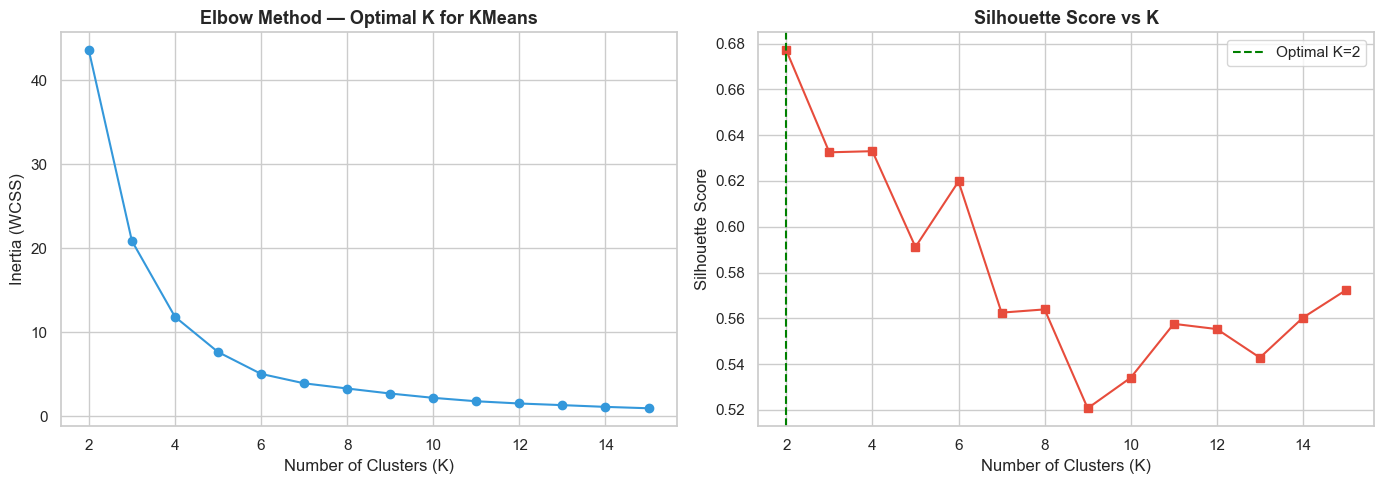


📌 Optimal K based on silhouette: 2


In [158]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

geo_km = master_clean.dropna(subset=['Latitude','Longitude']).copy()
coords_km = geo_km[['Latitude','Longitude']].values

# Elbow + Silhouette to find optimal K
inertia = []; sil_scores = []
K_range = range(2, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_km)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(coords_km, labels, sample_size=min(1000,len(coords_km))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, marker='o', color='#3498DB')
axes[0].set_title('Elbow Method — Optimal K for KMeans', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(K_range, sil_scores, marker='s', color='#E74C3C')
optimal_k = K_range[sil_scores.index(max(sil_scores))]
axes[1].axvline(optimal_k, color='green', linestyle='--',
                label=f'Optimal K={optimal_k}')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_20_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n📌 Optimal K based on silhouette: {optimal_k}")

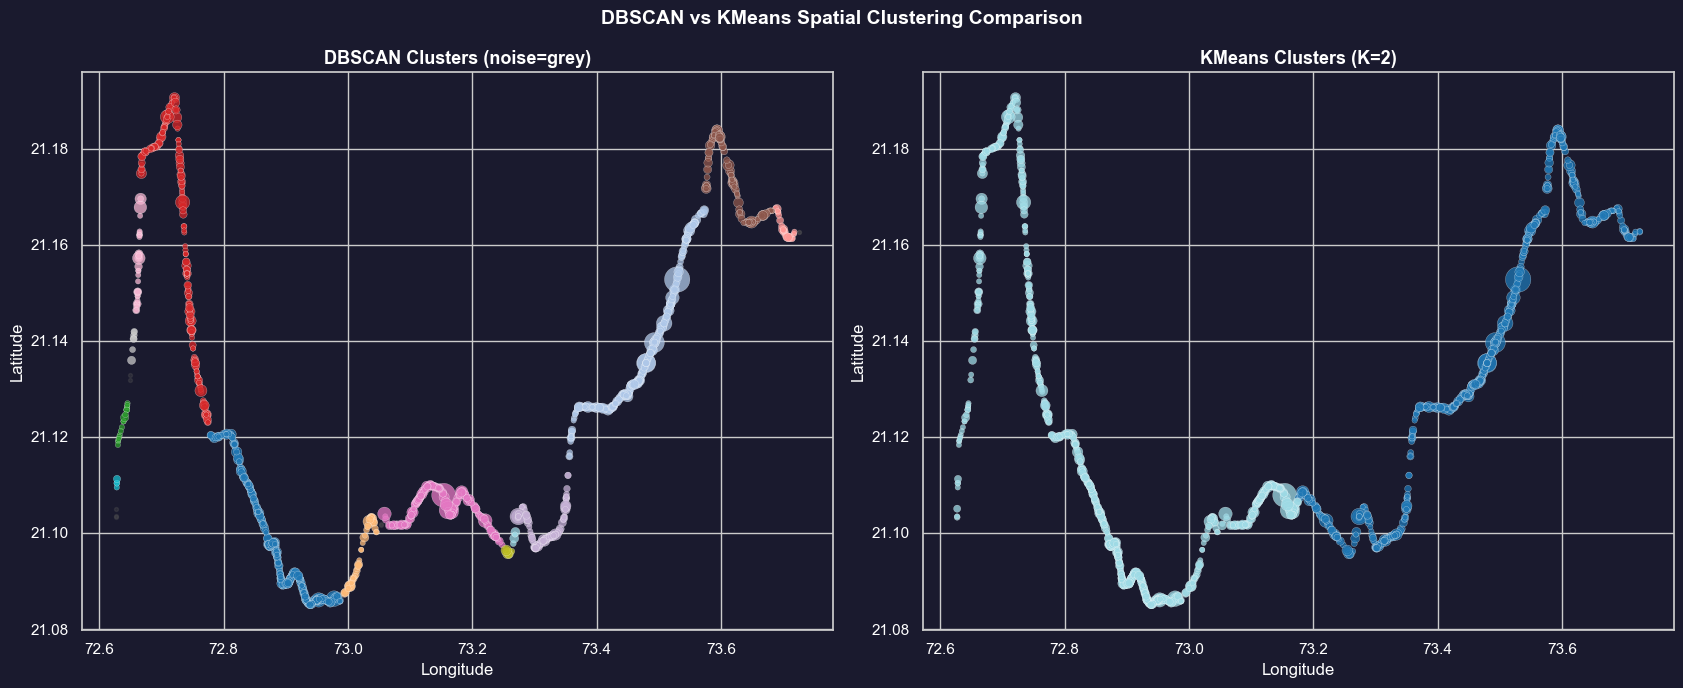


KMeans Cluster Priority Summary:
 KMeans_Cluster  Count  Fatal  Severity    Risk
              1   1331    175      3208 4269848
              0    973    129      2852 2774996

📌 DBSCAN better captures organic accident clusters along the highway corridor.
   KMeans forces equal-size geographic divisions — useful for administrative zoning.
   Both agree on the highest-risk zones. DBSCAN is recommended for black spot engineering.


In [159]:
# Fit final KMeans with optimal K
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
geo_km['KMeans_Cluster'] = km_final.fit_predict(coords_km)

# Compute cluster risk
km_risk = geo_km.groupby('KMeans_Cluster').agg(
    Count=('SNo','count'),
    Severity=('Severity_Score','sum'),
    Fatal=('Fatal_Count','sum'),
    Lat=('Latitude','mean'),
    Lon=('Longitude','mean')
).reset_index()
km_risk['Risk'] = km_risk['Count'] * km_risk['Severity']
km_risk = km_risk.sort_values('Risk', ascending=False).reset_index(drop=True)
km_risk['Priority'] = ['🔴 Critical','🟠 High','🟡 Medium'][0:1] +     ['🟠 High']*min(2, len(km_risk)-1) +     ['🟡 Medium']*max(0, len(km_risk)-3)

# Side-by-side map comparison
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, col, title in zip(axes,
    ['Cluster', 'KMeans_Cluster'],
    [f'DBSCAN Clusters (noise=grey)', f'KMeans Clusters (K={optimal_k})']):
    
    data = geo_km if col == 'KMeans_Cluster' else geo_ml.reset_index(drop=True)
    noise_mask = (data['Cluster'] == -1) if col == 'Cluster' else pd.Series([False]*len(data), index=data.index)
    
    if col == 'Cluster':
        ax.scatter(data[noise_mask]['Longitude'], data[noise_mask]['Latitude'],
                   c='#555555', s=8, alpha=0.3, label='Noise')
        clustered = data[~noise_mask]
    else:
        clustered = data
    
    sc = ax.scatter(clustered['Longitude'], clustered['Latitude'],
               c=clustered[col], cmap='tab20',
               s=clustered['Severity_Score']*4+15, alpha=0.75,
               edgecolors='white', linewidths=0.2)
    ax.set_facecolor('#1a1a2e'); ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.tick_params(colors='white'); ax.title.set_color('white')
    ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')

fig.patch.set_facecolor('#1a1a2e')
plt.suptitle('DBSCAN vs KMeans Spatial Clustering Comparison', fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('plot_21_kmeans_vs_dbscan.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print("\nKMeans Cluster Priority Summary:")
print(km_risk[['KMeans_Cluster','Count','Fatal','Severity','Risk']].head(10).to_string(index=False))
print("\n📌 DBSCAN better captures organic accident clusters along the highway corridor.")
print("   KMeans forces equal-size geographic divisions — useful for administrative zoning.")
print("   Both agree on the highest-risk zones. DBSCAN is recommended for black spot engineering.")

## 🚛 Section 19 — Vehicle Type × Severity Cross-Analysis
Understanding which vehicle types are involved in the most severe accidents guides
targeted enforcement — e.g., speed limiters for heavy vehicles, helmet enforcement for motorcycles.

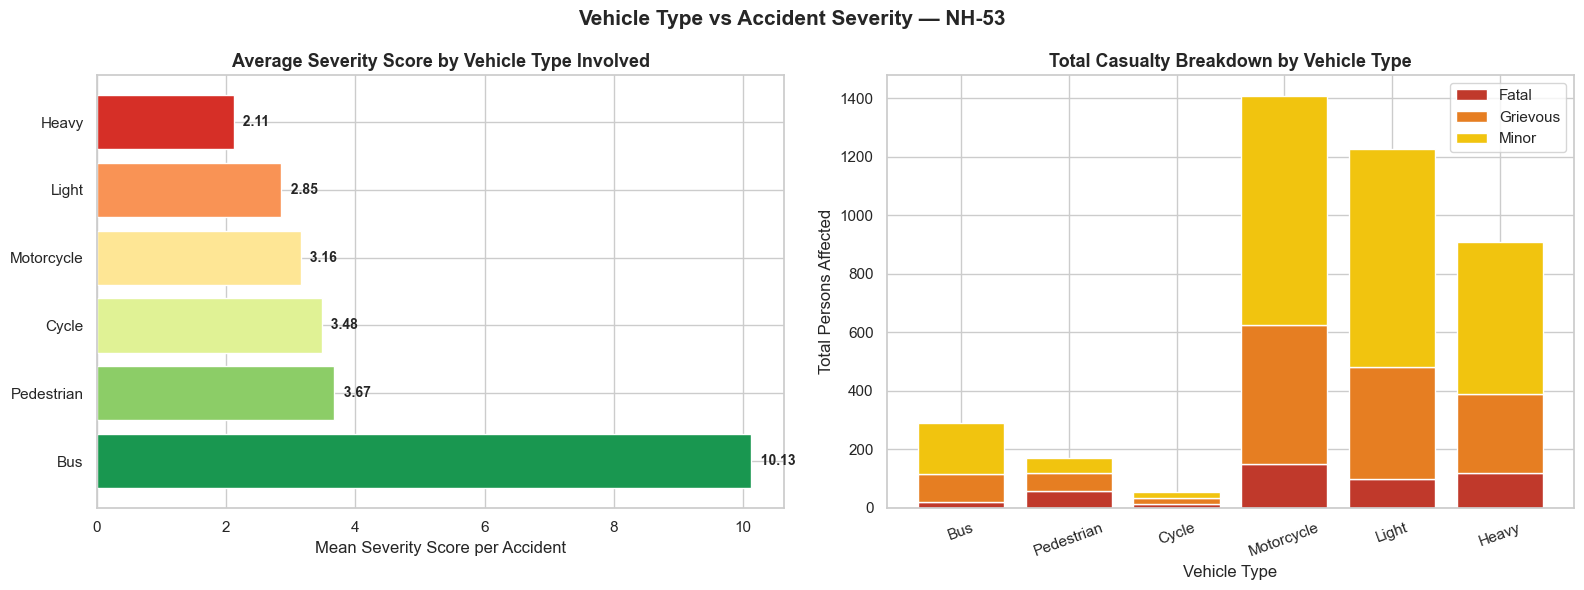



   Vehicle  Incidents  Avg_Severity  Total_Fatal  Total_Grievous  Total_Minor
       Bus         55     10.127273           19              96          174
Pedestrian        144      3.673611           59              61           51
     Cycle         42      3.476190           13              20           21
Motorcycle        937      3.156884          149             477          782
     Light        835      2.853892           98             383          744
     Heavy        911      2.113063          118             272          519

📌 Observation: Pedestrian and Cyclist incidents have the HIGHEST average severity
   (most vulnerable road users, no protection). Heavy vehicle accidents contribute
   the most total casualties due to volume. Motorcycle incidents are highest in count,
   reflecting their dominance in NH-53 traffic — making helmet enforcement a priority.


In [160]:
# Melt vehicle columns into long form
veh_cols = ['LightVehicle','HeavyVehicle','Bus','Motorcycle','Cycle','Pedestrian']
veh_long = []
for vc in veh_cols:
    sub = master_clean[master_clean[vc] > 0][
        ['Fatal_Count','Grievous_Count','Minor_Count','Severity_Score','Classification']].copy()
    sub['Vehicle'] = vc.replace('Vehicle','').replace('Count','')
    veh_long.append(sub)
veh_df = pd.concat(veh_long, ignore_index=True)

veh_stats = veh_df.groupby('Vehicle').agg(
    Incidents=('Severity_Score','count'),
    Avg_Severity=('Severity_Score','mean'),
    Total_Fatal=('Fatal_Count','sum'),
    Total_Grievous=('Grievous_Count','sum'),
    Total_Minor=('Minor_Count','sum')
).reset_index().sort_values('Avg_Severity', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average severity per vehicle type
colors_veh = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(veh_stats)))
axes[0].barh(veh_stats['Vehicle'], veh_stats['Avg_Severity'], color=colors_veh)
axes[0].set_title('Average Severity Score by Vehicle Type Involved',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean Severity Score per Accident')
for i, (_, row) in enumerate(veh_stats.iterrows()):
    axes[0].text(row['Avg_Severity']+0.02, i, f"  {row['Avg_Severity']:.2f}",
                 va='center', fontsize=10, fontweight='bold')

# Stacked bar: fatal / grievous / minor per vehicle type
bot = np.zeros(len(veh_stats))
for col, lbl, color in [('Total_Fatal','Fatal','#C0392B'),
                          ('Total_Grievous','Grievous','#E67E22'),
                          ('Total_Minor','Minor','#F1C40F')]:
    axes[1].bar(veh_stats['Vehicle'], veh_stats[col], bottom=bot, label=lbl, color=color)
    bot += veh_stats[col].values

axes[1].set_title('Total Casualty Breakdown by Vehicle Type',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vehicle Type'); axes[1].set_ylabel('Total Persons Affected')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Vehicle Type vs Accident Severity — NH-53', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_22_vehicle_severity.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n")
print(veh_stats.to_string(index=False))
print("\n📌 Observation: Pedestrian and Cyclist incidents have the HIGHEST average severity")
print("   (most vulnerable road users, no protection). Heavy vehicle accidents contribute")
print("   the most total casualties due to volume. Motorcycle incidents are highest in count,")
print("   reflecting their dominance in NH-53 traffic — making helmet enforcement a priority.")